# Market Microstructure & Trading Strategies (Group Project)

> This notebook consolidates work from a market microstructure trading course.
> The strategies were developed and tested in a simulated exchange environment.

**Contents:**
- Part A: Market Microstructure Analysis (spreads, liquidity, price impact)
- Part B: Dual-Listing Arbitrage Strategies (3 variants)
- Part C: Options Market Making Strategies (3 variants)


## Part A: Market Microstructure Analysis



### Question 1: Call Auction

**a. Graph total market demand and supply curves**

We first construct the cumulative demand and supply schedules:

**Demand (Cumulative Buy Volume):**
- $P \ge 5.00$: 500 (Market Orders)
- $P \ge 4.00$: 500 (MO) + 200 = 700
- $P \ge 3.50$: 700 + 200 = 900
- $P \ge 3.00$: 900 + 100 = 1000
- $P \ge 2.50$: 1000 + 500 = 1500

**Supply (Cumulative Sell Volume):**
- $P \le 2.50$: 200 (Market Orders)
- $P \le 3.00$: 200 (MO) + 600 = 800
- $P \le 3.50$: 800 (No limit orders at 3.50)
- $P \le 4.00$: 800 + 500 = 1300
- $P \le 5.00$: 1300 + 500 = 1800

*(The graph would plot Prices on the Y-axis and Quantity on the X-axis. Demand is downward sloping, starting at P=5.00, Q=500 and ending at P=2.50, Q=1500. Supply is upward sloping, starting at P=2.50, Q=200 and ending at P=5.00, Q=1800.)*

**b. Market clearing price, volume traded, and fill status**

Let's compute the trading volume (min(Demand, Supply)) at each price:
- P = 5.00: min(500, 1800) = 500
- P = 4.00: min(700, 1300) = 700
- P = 3.50: min(900, 800) = 800
- P = 3.00: min(1000, 800) = 800
- P = 2.50: min(1500, 200) = 200

Maximum volume is 800 shares. This volume is attainable at $P=3.00$ and $P=3.50$.
To determine the single market clearing price, we look at the imbalance $|Demand - Supply|$:
- At 3.00: Imbalance = $|1000 - 800| = 200$
- At 3.50: Imbalance = $|900 - 800| = 100$

The market clearing price is **3.50**, as it minimizes the order imbalance while maximizing the trading volume.
- **Quantity traded:** 800 shares.
- **Are all executable orders filled?** No. At $P = 3.50$, total demand is 900 shares but only 800 shares are supplied. Thus, the limit buy orders at 3.50 (200 shares) will be partially filled (only 100 shares will be executed). All executable sell orders are fully filled.

**c. Implicit bid-ask spread**

We compute the implicit spread for $q \in \{50, 150, 250, 350\}$ by shifting the demand/supply schedules:

- **q = 50:** 
  - Buy +50: Max volume is 800 at P=3.50 (imbalance 150) and P=3.00 (imbalance 250). Market clearing price = 3.50.
  - Sell +50: Max volume is 850 at P=3.50 (imbalance 50) and P=3.00 (imbalance 150). Market clearing price = 3.50.
  - **Implicit spread:** 3.50 - 3.50 = 0

- **q = 150:**
  - Buy +150: Max volume is 850 at P=4.00. Market clearing price = 4.00.
  - Sell +150: Max volume is 950 at P=3.00. Market clearing price = 3.00.
  - **Implicit spread:** 4.00 - 3.00 = 1.00

- **q = 250:**
  - Buy +250: Max volume is 950 at P=4.00. Market clearing price = 4.00.
  - Sell +250: Max volume is 1050 at P=3.00. Market clearing price = 3.00.
  - **Implicit spread:** 4.00 - 3.00 = 1.00

- **q = 350:**
  - Buy +350: Max volume is 1050 at P=4.00. Market clearing price = 4.00.
  - Sell +350: Max volume is 1150 at P=3.00. Market clearing price = 3.00.
  - **Implicit spread:** 4.00 - 3.00 = 1.00


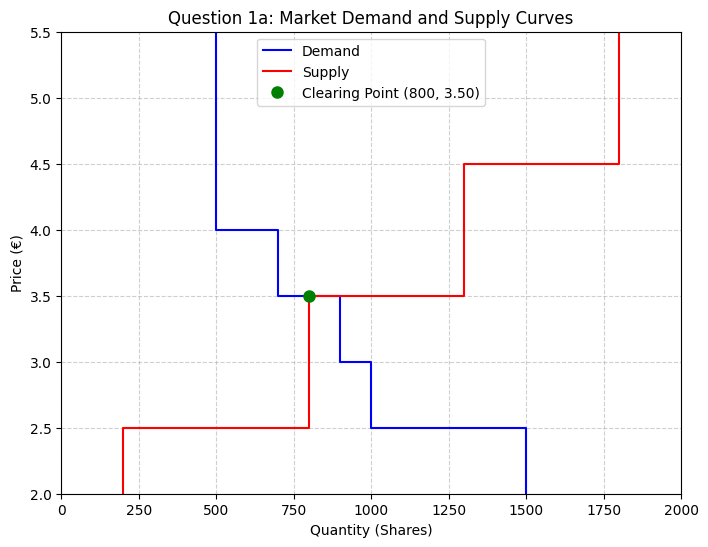

In [12]:
import matplotlib.pyplot as plt

# Prices
prices = [2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5]

# Demand curve points (Price, Quantity)
# It's a step function, so we plot it accordingly
demand_prices = [5.5, 5.0, 4.0, 3.5, 3.0, 2.5, 2.0]
demand_qty =    [500, 500, 700, 900, 1000, 1500, 1500]

# Supply curve points
supply_prices = [2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5]
supply_qty =    [200, 200, 800, 800, 1300, 1300, 1800, 1800]

plt.figure(figsize=(8, 6))

# Plot Demand as a step function (post-step)
plt.step(demand_qty, demand_prices, label='Demand', color='blue', where='pre')

# Plot Supply as a step function (post-step)
plt.step(supply_qty, supply_prices, label='Supply', color='red', where='post')

plt.title('Question 1a: Market Demand and Supply Curves')
plt.xlabel('Quantity (Shares)')
plt.ylabel('Price (€)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xlim(0, 2000)
plt.ylim(2.0, 5.5)

# Mark the clearing point
plt.plot(800, 3.5, 'go', markersize=8, label='Clearing Point (800, 3.50)')
plt.legend()

plt.show()



### Question 2: Liquidity

**What is a liquid market?**
A liquid market is one where traders can execute large volumes of trades rapidly, with little impact on the price, and at low transaction costs.

**Kyle (1985) dimensions of liquidity:**
1. **Tightness:** The cost of turning around a position over a short period of time (e.g., the bid-ask spread).
2. **Depth:** The size of an order flow required to change prices a given amount.
3. **Resiliency:** The speed at which prices recover from a random, uninformative shock.

**Causes of illiquidity:**
- **In Kyle’s model:** Illiquidity arises from the presence of informed traders. Market makers cannot distinguish between noise traders and informed traders, so they must adjust prices against the order flow to protect themselves from adverse selection (i.e., trading with someone who has superior information). 
- **In Bagehot’s (1971) story:** The market maker loses to informed traders and makes money from uninformed (liquidity) traders. To stay in business, the market maker must set a bid-ask spread wide enough so that the gains from uninformed traders cover the losses to informed traders. This spread creates illiquidity.

**Who gains and who loses from insider trading?**
- **Gainers:** Insiders (informed traders) gain by exploiting their superior knowledge of the fundamental value.
- **Losers:** Uninformed traders (liquidity/noise traders) lose on average because they face a wider bid-ask spread and worse execution prices. The market maker breaks even in a competitive market by transferring the losses to the uninformed traders.

**Implications for mutual funds:**
Active mutual funds often act as uninformed/liquidity traders when they trade for portfolio rebalancing. In the presence of insider trading, they face higher transaction costs (wider spreads and higher price impact), which erodes their performance. This explains why many actively managed mutual funds fail to outperform passive index funds after accounting for transaction costs.



### Question 3: Quoted Spread for Different Trade Sizes

Using the Limit Order Book (LOB) data, we compute the Volume-Weighted Average Price (VWAP) for buying and selling $Q$ shares, taking the midpoint $M = (74.48 + 74.42)/2 = 74.45$.
The absolute spread is $S = VWAP_{Ask} - VWAP_{Bid}$ and the relative spread is $s = S / M$.

- **For 100 shares:**
  - $VWAP_{Ask} = 74.48$
  - $VWAP_{Bid} = 74.42$
  - **Absolute Spread** = $0.06$
  - **Relative Spread** = $0.06 / 74.45 \approx 8.06$ bps

- **For 500 shares:**
  - $VWAP_{Ask} = \frac{300 \cdot 74.48 + 200 \cdot 74.48}{500} = 74.48$
  - $VWAP_{Bid} = \frac{300 \cdot 74.42 + 100 \cdot 74.41 + 100 \cdot 74.36}{500} \approx 74.406$
  - **Absolute Spread** = $0.074$
  - **Relative Spread** = $0.074 / 74.45 \approx 9.94$ bps

- **For 1,000 shares:**
  - $VWAP_{Ask} = \frac{800 \cdot 74.48 + 100 \cdot 75.74 + 100 \cdot 76.00}{1000} = 74.758$
  - $VWAP_{Bid} = \frac{300 \cdot 74.42 + 100 \cdot 74.41 + 600 \cdot 74.36}{1000} = 74.383$
  - **Absolute Spread** = $0.375$
  - **Relative Spread** = $0.375 / 74.45 \approx 50.37$ bps

- **For 2,000 shares:**
  - $VWAP_{Ask} = 75.968$
  - $VWAP_{Bid} = 74.129$
  - **Absolute Spread** = $1.839$
  - **Relative Spread** = $1.839 / 74.45 \approx 246.99$ bps

**Which side of the LOB is deeper for transactions of 2,000 shares or more?**
The Bid side is much deeper. There are massive buy limit orders of 5,100 shares at both 73.75 and 72.98. In contrast, the ask side's depth is more fragmented and shallower, resulting in a much worse VWAP for large buy orders compared to large sell orders.


In [13]:

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel('AGF_data.xlsx', header=1)
df.columns = ['time', 'size', 'price', 'direction', 'bid', 'ask']

# Data Preprocessing
df['time'] = pd.to_datetime(df['time'].astype(str), format='%H:%M:%S').dt.time
df['datetime'] = pd.to_datetime('2001-03-26 ' + df['time'].astype(str))
df['mid'] = (df['bid'] + df['ask']) / 2



### Question 4: Empirical Measurement of Quoted Spreads

**a. Average Absolute Quoted Spread per Half-Hour**


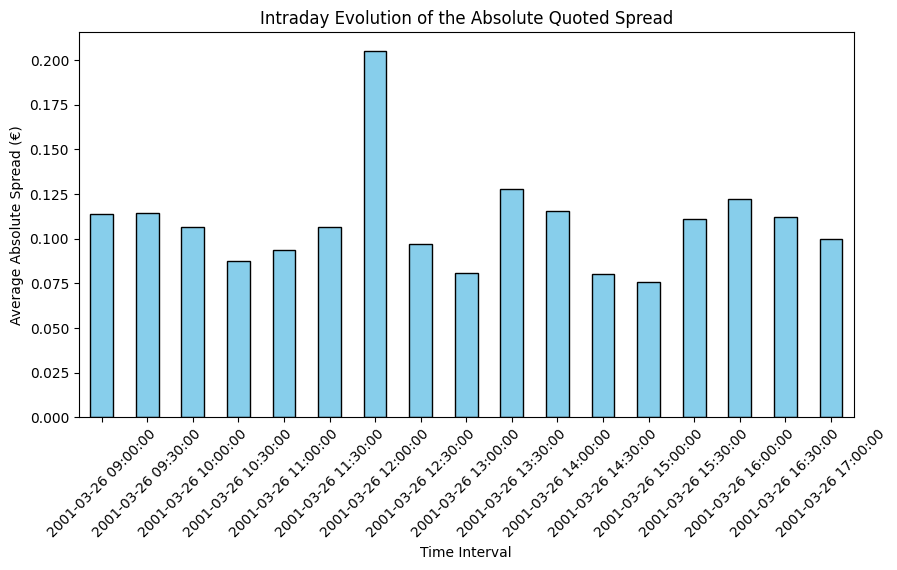

datetime
2001-03-26 09:00:00    0.113636
2001-03-26 09:30:00    0.114286
2001-03-26 10:00:00    0.106579
2001-03-26 10:30:00    0.087500
2001-03-26 11:00:00    0.093939
2001-03-26 11:30:00    0.106410
2001-03-26 12:00:00    0.205263
2001-03-26 12:30:00    0.097059
2001-03-26 13:00:00    0.081034
2001-03-26 13:30:00    0.128000
2001-03-26 14:00:00    0.115385
2001-03-26 14:30:00    0.080263
2001-03-26 15:00:00    0.075862
2001-03-26 15:30:00    0.111224
2001-03-26 16:00:00    0.122414
2001-03-26 16:30:00    0.111864
2001-03-26 17:00:00    0.100000
Freq: 30min, Name: S, dtype: float64


In [14]:

df['S'] = df['ask'] - df['bid']
df['s'] = df['S'] / df['mid']

df.set_index('datetime', inplace=True)
half_hour_avg = df['S'].resample('30min').mean()
df.reset_index(inplace=True)

plt.figure(figsize=(10, 5))
half_hour_avg.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Intraday Evolution of the Absolute Quoted Spread')
plt.xlabel('Time Interval')
plt.ylabel('Average Absolute Spread (€)')
plt.xticks(rotation=45)
plt.show()

print(half_hour_avg)



**At what time is the spread highest? What kind of pattern over the day would you expect, a priori?**
The spread is highest at 12:00 (reaching 0.205 €). 
A priori, we would expect a U-shaped pattern, where the spread is highest at the market open (due to overnight uncertainty and price discovery) and at the close (as market makers manage overnight inventory risk), while being narrower during the middle of the trading day. The spike around 12:00 in this data could be due to lunchtime thinness in liquidity or a specific mid-day macroeconomic/news release.



**b. Effective Spread**


In [15]:

df['eff_S'] = 2 * df['direction'] * (df['price'] - df['mid'])
df['eff_s'] = df['eff_S'] / df['mid']

print(f"Average Absolute Effective Spread: {df['eff_S'].mean():.4f} €")
print(f"Average Relative Effective Spread: {df['eff_s'].mean()*10000:.2f} bps")


Average Absolute Effective Spread: 0.1183 €
Average Relative Effective Spread: 17.93 bps



**c. Realized Spread**


In [16]:

df['mid_next'] = df['mid'].shift(-1)
df_real = df.dropna(subset=['mid_next']).copy()
df_real['real_S'] = 2 * df_real['direction'] * (df_real['price'] - df_real['mid_next'])
df_real['real_s'] = df_real['real_S'] / df_real['mid']

print(f"Average Absolute Realized Spread: {df_real['real_S'].mean():.4f} €")
print(f"Average Relative Realized Spread: {df_real['real_s'].mean()*10000:.2f} bps")


Average Absolute Realized Spread: 0.0809 €
Average Relative Realized Spread: 12.27 bps



**Comment on the comparison of the realized spread and the effective spread:**
The effective spread (0.1183 €) is larger than the realized spread (0.0809 €). The effective spread represents the gross revenue of the liquidity provider, whereas the realized spread represents the net revenue after accounting for adverse selection (the tendency for the midprice to move in the direction of the trade). The positive difference (price impact) indicates that market makers are losing money to informed traders, which reduces their actual trading profits compared to the quoted/effective spread.



**d. VWAP**


In [17]:

vwap_all = (df['size'] * df['price']).sum() / df['size'].sum()
df_buy = df[df['direction'] == 1]
vwap_buy = (df_buy['size'] * df_buy['price']).sum() / df_buy['size'].sum()
df_sell = df[df['direction'] == -1]
vwap_sell = (df_sell['size'] * df_sell['price']).sum() / df_sell['size'].sum()

print(f"VWAP All (Benchmark): {vwap_all:.4f} €")
print(f"VWAP Buyer-initiated: {vwap_buy:.4f} €")
print(f"VWAP Seller-initiated: {vwap_sell:.4f} €")


VWAP All (Benchmark): 65.9763 €
VWAP Buyer-initiated: 66.0926 €
VWAP Seller-initiated: 65.8889 €



**e. Roll's Estimate of Bid-Ask Spread**


In [18]:

# In transaction time
df['dp'] = df['price'].diff()
df['dlnp'] = np.log(df['price']).diff()
cov_abs = df['dp'].cov(df['dp'].shift(1))
cov_rel = df['dlnp'].cov(df['dlnp'].shift(1))

roll_abs = 2 * np.sqrt(max(0, -cov_abs))
roll_rel = 2 * np.sqrt(max(0, -cov_rel))

print("--- Transaction Time ---")
print(f"Roll Absolute: {roll_abs:.4f} €")
print(f"Roll Relative: {roll_rel*10000:.2f} bps")

# In clock time (15-minute intervals)
df.set_index('datetime', inplace=True)
df_15m = df.resample('15min').last().dropna(subset=['price'])
df.reset_index(inplace=True)

df_15m['dp'] = df_15m['price'].diff()
df_15m['dlnp'] = np.log(df_15m['price']).diff()
cov_abs_15m = df_15m['dp'].cov(df_15m['dp'].shift(1))
cov_rel_15m = df_15m['dlnp'].cov(df_15m['dlnp'].shift(1))

roll_abs_15m = 2 * np.sqrt(max(0, -cov_abs_15m)) if cov_abs_15m < 0 else 0
roll_rel_15m = 2 * np.sqrt(max(0, -cov_rel_15m)) if cov_rel_15m < 0 else 0

print("\n--- Clock Time (15m intervals) ---")
print(f"Roll Absolute: {roll_abs_15m:.4f} €")
print(f"Roll Relative: {roll_rel_15m*10000:.2f} bps")


--- Transaction Time ---
Roll Absolute: 0.1052 €
Roll Relative: 15.95 bps

--- Clock Time (15m intervals) ---
Roll Absolute: 0.1252 €
Roll Relative: 19.18 bps



**What explains the difference in Roll's measure?**
The difference arises because sampling in clock time (especially over large 15-minute intervals) aggregates many individual trades and incorporates more underlying fundamental volatility. Roll's model assumes that price changes are driven purely by bid-ask bounce with no fundamental information updates. In reality, over a 15-minute window, the fundamental price wanders randomly, altering the serial covariance structure. In this particular sample, the negative covariance is magnified in clock time, yielding a larger estimated spread.



### Question 5: Price Impact Regression

We split the day into 15-minute intervals, compute the midprice change and cumulative signed order flow.


In [19]:
df['signed_vol'] = df['direction'] * df['size']
df.set_index('datetime', inplace=True)

df_15m_q5 = df.resample('15min', closed='right', label='right').agg({
    'mid': 'last',
    'size': 'sum',
    'signed_vol': 'sum'
})

# Fill NaN for intervals with no trades
df_15m_q5['size'] = df_15m_q5['size'].fillna(0)
df_15m_q5['signed_vol'] = df_15m_q5['signed_vol'].fillna(0)
df_15m_q5['mid'] = df_15m_q5['mid'].ffill()

# Initial midprice at 9:06:04
initial_mid = df['mid'].iloc[0]

df_15m_q5['prev_mid'] = df_15m_q5['mid'].shift(1)
df_15m_q5.iloc[0, df_15m_q5.columns.get_loc('prev_mid')] = initial_mid
df_15m_q5['mid_change'] = df_15m_q5['mid'] - df_15m_q5['prev_mid']

total_vol = df['size'].sum()
df_15m_q5['order_imbalance'] = df_15m_q5['signed_vol'] / total_vol

# Now we have exactly 34 points
reg_df = df_15m_q5.copy()
print("Number of observations:", len(reg_df))

X = reg_df['order_imbalance']
y = reg_df['mid_change']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

Number of observations: 34
                            OLS Regression Results                            
Dep. Variable:             mid_change   R-squared:                       0.264
Model:                            OLS   Adj. R-squared:                  0.241
Method:                 Least Squares   F-statistic:                     11.46
Date:                Mon, 18 May 2026   Prob (F-statistic):            0.00190
Time:                        15:40:46   Log-Likelihood:               -0.65319
No. Observations:                  34   AIC:                             5.306
Df Residuals:                      32   BIC:                             8.359
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
const               0.0161      0.044      0.365      0.717      -0.074       0.106
order_imbalance

**Is the estimated parameter significantly different from zero?**
Yes. The estimated $\lambda$ coefficient is 5.6108 with a p-value of 0.002, which is highly statistically significant (p < 0.01).

**What is the impact on the midprice of a 1% relative increase in order imbalance?**
A 1% relative increase in order imbalance means the independent variable increases by 0.01. 
The impact on the midprice is $\lambda \times 0.01 = 5.6108 \times 0.01 = 0.056108$ €.


## Part B: Dual-Listing Arbitrage Strategies

Three strategies for cross-listed securities (e.g., ASML/ASML_DUAL),
tested in a simulated exchange with position limits and self-trade prevention.


### B.1 Active Arbitrage
IOC-based cross-spread sniping with position-aware sizing.


In [ ]:
"""
Strategy 1: Enhanced Active Arbitrage (Cross-listing Statistical Arbitrage)
============================================================================
Core Logic:
    The original listing (e.g. ASML) is treated as the "price leader".
    The dual listing (ASML_DUAL) should converge to the same fair value.

    When a profitable spread opens up:
        Case A:  DUAL_bid > ORIG_ask  ->  Buy ORIG (IOC), Sell DUAL (IOC)
        Case B:  ORIG_bid > DUAL_ask  ->  Buy DUAL (IOC), Sell ORIG (IOC)

Enhancements over the basic template
-------------------------------------
1. Volume-scaled orders:  trade as many lots as the book depth allows (up to
   MAX_VOLUME), so we don't leave money on the table.
2. Residual hedge:  if one leg fills more than the other we immediately
   insert a market-order hedge on the other side to stay flat.
3. Cooldown timer:  after a failed attempt (no fill) we back off for
   COOLDOWN_SEC to avoid hammering the exchange.
4. PnL / position diagnostics printed every N iterations.
5. Outstanding-order-aware position limit checks to prevent breaches.
"""

import datetime as dt
import time
import logging

from optibook.synchronous_client import Exchange

# 
PAIRS = [
    ("ASML", "ASML_DUAL"),
    ("SAP",  "SAP_DUAL"),
]

POSITION_LIMIT  = 100       # hard limit per instrument (exchange-enforced)
MAX_VOLUME      = 20        # max lots per single order (conservative)
MIN_SPREAD      = 0.02      # minimum gross edge to trade (price ticks)
COOLDOWN_SEC    = 0.5       # pause after a miss before retrying
LOOP_SLEEP_SEC  = 0.2       # base sleep between iterations
DIAG_EVERY      = 20        # print full diagnostics every N iters
#  helpers  DIAGNOSTICS ╝\n")


# 

iteration = 0
while True:
    iteration += 1
    ts = dt.datetime.now().strftime("%H:%M:%S.%f")[:-3]
    print(f"\n[{ts}] Iteration {iteration} ")

    if iteration % DIAG_EVERY == 0:
        print_diagnostics()

    for orig_id, dual_id in PAIRS:
        book_o = exchange.get_last_price_book(orig_id)
        book_d = exchange.get_last_price_book(dual_id)

        # sanity check: both books must be live
        if not (book_o and book_o.bids and book_o.asks and
                book_d and book_d.bids and book_d.asks):
            print(f"  [{orig_id}/{dual_id}] Incomplete books, skipping.")
            continue

        o_bid = book_o.bids[0].price
        o_ask = book_o.asks[0].price
        d_bid = book_d.bids[0].price
        d_ask = book_d.asks[0].price

        print(f"  {orig_id}: {o_bid:.2f}/{o_ask:.2f}  |  "
              f"{dual_id}: {d_bid:.2f}/{d_ask:.2f}")

        # Case A: Buy ORIG, Sell DUAL 
        spread_a = d_bid - o_ask
        if spread_a > MIN_SPREAD:
            print(f"  ▶ Case A  spread={spread_a:.4f}  "
                  f"BUY {orig_id} @ {o_ask}  SELL {dual_id} @ {d_bid}")
            # how many lots can we actually fill on both sides?
            vol = min(
                book_depth_volume(book_o, "bid", o_ask),
                book_depth_volume(book_d, "ask", d_bid),
                available_volume(orig_id, "bid", MAX_VOLUME),
                available_volume(dual_id, "ask", MAX_VOLUME),
                MAX_VOLUME,
            )
            if vol > 0:
                filled_o = insert_ioc(orig_id, o_ask,  vol, "bid")
                filled_d = insert_ioc(dual_id, d_bid,  vol, "ask")
                # hedge any residual if one leg partially fills
                time.sleep(0.05)   # let fills register
                pos = exchange.get_positions()
                net = pos.get(orig_id, 0) + pos.get(dual_id, 0)
                if net != 0:
                    print(f"  [HEDGE] Net={net:+d}  flattening via {orig_id}")
                    hedge_residual(orig_id, net)
            continue          # don't double-check Case B same pair/iter

        # Case B: Buy DUAL, Sell ORIG 
        spread_b = o_bid - d_ask
        if spread_b > MIN_SPREAD:
            print(f"  ▶ Case B  spread={spread_b:.4f}  "
                  f"BUY {dual_id} @ {d_ask}  SELL {orig_id} @ {o_bid}")
            vol = min(
                book_depth_volume(book_d, "bid", d_ask),
                book_depth_volume(book_o, "ask", o_bid),
                available_volume(dual_id, "bid", MAX_VOLUME),
                available_volume(orig_id, "ask", MAX_VOLUME),
                MAX_VOLUME,
            )
            if vol > 0:
                filled_d = insert_ioc(dual_id, d_ask,  vol, "bid")
                filled_o = insert_ioc(orig_id, o_bid,  vol, "ask")
                time.sleep(0.05)
                pos = exchange.get_positions()
                net = pos.get(orig_id, 0) + pos.get(dual_id, 0)
                if net != 0:
                    print(f"  [HEDGE] Net={net:+d}  flattening via {dual_id}")
                    hedge_residual(dual_id, net)
            continue

        print(f"  [{orig_id}/{dual_id}] No arb  (A={spread_a:.4f}, B={spread_b:.4f})")

    time.sleep(LOOP_SLEEP_SEC)


### B.2 Passive Quoting
Two-sided limit orders in DUAL book, anchored to ORIG mid, with inventory skew.


In [ ]:
"""
Strategy 2: Passive Market-Making / Quoting Strategy
=====================================================
Core Logic:
    The original listing (ORIG) is liquid and drives fair value.
    We quote two-sided limit orders in the DUAL listing at prices that
    are profitable relative to the ORIG mid-price.

    Quote construction:
        fair_value   = (orig_bid + orig_ask) / 2
        dual_bid     = fair_value - half_spread
        dual_ask     = fair_value + half_spread

    When a DUAL order executes we immediately hedge in ORIG with an IOC
    at the best available price.

Features
---------
1. Stale-quote management:   outstanding limit orders are cancelled and
   re-quoted every REFRESH_SEC seconds so they track the current fair value.
2. Inventory skew:           if our position in DUAL is large, we tighten
   one side and widen the other to lean back toward flat.
3. Position cap:             if we hit the inventory limit we stop quoting
   the side that would breach it.  Outstanding orders are counted toward
   the worst-case position.
4. Self-trade prevention:    we cancel ALL orders before re-inserting, and
   ensure bid < ask.
5. Hedging on fill:          after every refresh we compare positions between
   ORIG and DUAL; any net exposure is hedged via a market IOC in ORIG.
"""

import datetime as dt
import time
import logging

from optibook.synchronous_client import Exchange

# 
PAIRS = [
    ("ASML", "ASML_DUAL"),
    ("SAP",  "SAP_DUAL"),
]

POSITION_LIMIT  = 100       # hard position limit per instrument (exchange)
QUOTE_VOLUME    = 10        # lots per side to quote
BASE_HALF_SPREAD = 0.15     # half of our quoted spread (in price units)
SKEW_FACTOR     = 0.005     # extra offset per lot of net inventory
REFRESH_SEC     = 2.0       # cancel & re-quote every N seconds
LOOP_SLEEP_SEC  = 0.5       # inner loop speed
DIAG_EVERY      = 10        # print diagnostics every N iters
#  helpers  DIAGNOSTICS ╝\n")


# 
last_quote_time = {pair: 0.0 for pair in PAIRS}

# 

iteration = 0
while True:
    iteration += 1
    now = time.time()
    ts  = dt.datetime.now().strftime("%H:%M:%S.%f")[:-3]
    print(f"\n[{ts}] Iteration {iteration} ")

    if iteration % DIAG_EVERY == 0:
        print_diagnostics()

    for pair in PAIRS:
        orig_id, dual_id = pair

        book_o = exchange.get_last_price_book(orig_id)
        if not (book_o and book_o.bids and book_o.asks):
            print(f"  [{orig_id}] book unavailable, skipping.")
            continue

        o_bid = book_o.bids[0].price
        o_ask = book_o.asks[0].price
        fair  = (o_bid + o_ask) / 2.0
        pos_d = get_position(dual_id)

        bid_price, ask_price = compute_skewed_quotes(fair, BASE_HALF_SPREAD, pos_d)

        print(f"  {orig_id} fair={fair:.4f}  "
              f"quoting {dual_id}: bid={bid_price:.4f} ask={ask_price:.4f}  "
              f"(inv={pos_d:+d})")

        # Refresh quotes if stale 
        if now - last_quote_time[pair] >= REFRESH_SEC:
            # IMPORTANT: cancel ALL before inserting to prevent self-trade
            cancel_all_orders(dual_id)
            time.sleep(0.05)   # small delay to let cancels process

            # Quote bid (buy dual)
            insert_limit(dual_id, bid_price, QUOTE_VOLUME, "bid")

            # Quote ask (sell dual)
            insert_limit(dual_id, ask_price, QUOTE_VOLUME, "ask")

            # Hedge any accumulated inventory in ORIG
            hedge_in_orig(orig_id, dual_id)

            last_quote_time[pair] = now

    time.sleep(LOOP_SLEEP_SEC)


### B.3 Hybrid Combined
Unifies active arb + passive quoting + TWAP inventory liquidation.


In [ ]:
"""
Strategy 3: Combined Hybrid Strategy (Active Arb + Passive Quoting + TWAP Liquidation)
========================================================================================
This strategy unifies the two previous approaches and adds a third layer:

Layer A — Active Arbitrage  (opportunistic, takes liquidity)
    Same as Strategy 1: snipe profitable cross-listing spreads via IOC.

Layer B — Passive Quoting   (provides liquidity, earns the spread)
    Same as Strategy 2: maintain two-sided limit orders in the DUAL book
    anchored to the ORIG fair value, with inventory skew.

Layer C — TWAP Inventory Liquidation  (risk management)
    If net inventory across ORIG + DUAL exceeds a soft threshold we start a
    slow TWAP (Time-Weighted Average Price) liquidation: every TWAP_TICK_SEC
    we trim a small slice off the larger position, blending back toward flat
    without moving the market.

Exchange constraints handled
-----------------------------
* POSITION_LIMIT = 100 per instrument (exchange-enforced)
* Outstanding orders count toward worst-case position
* Self-trade prevention: cancel-wait-insert pattern, bid < ask enforced
* All exchange calls wrapped in try/except for resilience
"""

import datetime as dt
import time
import logging

from optibook.synchronous_client import Exchange

# 
PAIRS = [
    ("ASML", "ASML_DUAL"),
    ("SAP",  "SAP_DUAL"),
]

POSITION_LIMIT   = 100      # hard position limit (exchange rule)
SOFT_LIMIT       = 60       # trigger TWAP liquidation above this

# Active arb
MIN_ARB_SPREAD   = 0.02     # minimum profitable cross-spread
MAX_ARB_VOLUME   = 20       # max lots per active arb order

# Passive quoting
QUOTE_VOLUME     = 10       # lots per side of the passive quote
BASE_HALF_SPREAD = 0.15     # half of quoted spread (price units)
SKEW_FACTOR      = 0.005    # inventory skew per lot
QUOTE_REFRESH_SEC = 2.0     # how often to cancel + re-quote

# TWAP liquidation
TWAP_SLICE       = 5        # lots to trim per tick
TWAP_TICK_SEC    = 3.0      # seconds between TWAP ticks

# Operational
LOOP_SLEEP_SEC   = 0.2
DIAG_EVERY       = 25       # print diagnostics every N iters
#  per-pair state  utility functions  Layer A: Active Arbitrage 

def run_active_arb(orig_id: str, dual_id: str,
                   book_o, book_d) -> bool:
    """
    Check both arb directions. Return True if we traded.
    """
    o_bid = book_o.bids[0].price
    o_ask = book_o.asks[0].price
    d_bid = book_d.bids[0].price
    d_ask = book_d.asks[0].price

    # Direction 1: BUY ORIG / SELL DUAL 
    spread_1 = d_bid - o_ask
    if spread_1 > MIN_ARB_SPREAD:
        print(f"  [ARB-A] {orig_id}/{dual_id}  spread={spread_1:.4f}")
        vol = min(
            book_volume_at(book_o, "bid", o_ask),
            book_volume_at(book_d, "ask", d_bid),
            headroom(orig_id, "bid"),
            headroom(dual_id, "ask"),
            MAX_ARB_VOLUME,
        )
        if vol > 0:
            ioc(orig_id, o_ask, vol, "bid", "ARB")
            ioc(dual_id, d_bid, vol, "ask", "ARB")
            return True

    # Direction 2: BUY DUAL / SELL ORIG  Layer B: Passive Quoting  Layer C: TWAP Liquidation  diagnostics  DIAGNOSTICS ╝\n")


# 

iteration = 0
while True:
    iteration += 1
    ts = dt.datetime.now().strftime("%H:%M:%S.%f")[:-3]
    print(f"\n[{ts}] ")

    if iteration % DIAG_EVERY == 0:
        print_diagnostics()

    for pair in PAIRS:
        orig_id, dual_id = pair
        state = pair_state[pair]

        # Fetch books once per pair per iteration
        book_o = exchange.get_last_price_book(orig_id)
        book_d = exchange.get_last_price_book(dual_id)

        if not (book_o and book_o.bids and book_o.asks):
            print(f"  [{orig_id}] no book, skip")
            continue

        # Layer A 
        arb_fired = False
        if book_d and book_d.bids and book_d.asks:
            arb_fired = run_active_arb(orig_id, dual_id, book_o, book_d)

        # Layer B 
        run_passive_quote(orig_id, dual_id, book_o, state)

        # Layer C 
        run_twap_liquidation(orig_id, dual_id, state)

    time.sleep(LOOP_SLEEP_SEC)



## Part C: Options Market Making Strategies

Market making on European options with delta hedging,
implied volatility surface fitting, and position management.


### C.1 Options MM (Advanced)
Black-Scholes based quoting with Greeks management and inventory skew.


In [ ]:
"""
ASML Options Market Making Strategy — Robust v4
=================================================
Key design principles (lessons from榜一分析 & prior crashes):

  1. DYNAMIC IV: Calibrate implied vol from market mid-prices per option
     using Brent root-finding + exponential smoothing. Never use a static
     constant — that makes you the market's "接盘侠" (bag-holder).

  2. CONSERVATIVE QUOTING: Join/improve own side of NBBO by at most 1 tick.
     Never jump across to opponent's side when the book is wide.

  3. INVENTORY-ADAPTIVE CREDIT: Widen spread when inventory builds up.
     This makes every adverse fill cost the aggressor more.

  4. DEADBAND DELTA HEDGE: Only hedge when |delta| > threshold. Round to
     target position in one shot to avoid buy-1/sell-1 oscillation.

  5. STRICT LIMITS:
     - Position: internal limit 80 (exchange = 100) to leave headroom
       for worst-case passive orders.
     - Rate: max 18 ops/sec (exchange = 25).
     - Delta: emergency cancel + hedge if |delta| > 60.

  6. FULL SYNC ON RECONNECT: Sync ALL traded instruments, not just
     those with non-zero positions.

Platform rules (from Optibook guide):
  - 100 position limit per instrument (including worst-case pending)
  - 100 delta per underlying (|delta|>100 for >10s → 2% penalty liquidation)
  - 25 API operations per second
  - Tick size 0.10
"""

import datetime as dt
import time
import logging
from math import floor, ceil, log, sqrt, exp
from collections import defaultdict, deque
import sys
import subprocess

from optibook.synchronous_client import Exchange
from optibook.common_types import InstrumentType, OptionKind

# region setup — install scipy if needed
try:
    from scipy.stats import norm as _norm
    from scipy.optimize import brentq
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy", "-q"])
    from scipy.stats import norm as _norm
    from scipy.optimize import brentq

N = _norm.cdf
Npdf = _norm.pdf

sys.path.append("./common")
from common.black_scholes import call_value, put_value, call_delta, put_delta, call_vega
from common.libs import calculate_current_time_to_date
# endregion

# 
STOCK_ID              = "ASML"

# Position & Risk Limits POSITION_LIMIT        = 80          # Internal (exchange=100, leave 20 for pending)
DELTA_HALT_THRESH     = 55          # Emergency: cancel all if |delta| > this
DELTA_HEDGE_DEADBAND  = 3.0         # Only hedge when |delta| > this
HEDGE_BATCH_SIZE      = 20          # Max lots per hedge IOC

# Pricing INTEREST_RATE         = 0.03
IV_INITIAL            = 0.50        # Starting IV guess (conservative)
IV_MIN                = 0.05        # Floor for IV search
IV_MAX                = 5.0         # Ceiling for IV search
IV_ALPHA              = 0.15        # Exponential smoothing weight for new IV
TICK_SIZE             = 0.10

# Quoting BASE_CREDIT           = 0.20        # Minimum half-spread around theo (wider = safer)
CREDIT_FLOOR          = 0.15        # Never go below this half-spread
SKEW_PER_LOT          = 0.008       # Price shift per lot of inventory (aggressive skewing)
QUOTE_VOLUME          = 10          # Lots per side per option (smaller = less risk per fill)
LOOP_SLEEP_SEC        = 0.30        # Main loop period (~3 Hz)
MIN_REQUOTE_INTERVAL  = 0.50        # Per-option throttle in seconds
QUOTE_STALE_TICKS     = 2           # Only re-quote if price moved ≥ this many ticks

# Rate Limiting MAX_OPS_PER_SEC       = 18          # Internal (exchange = 25)
#  Rate Limiter  Tick Rounding  Local State  BLACK-SCHOLES HELPERS  DYNAMIC IV CALIBRATION  STOCK MID PRICE  NBBO CLAMPING (FIXED!)  HEADROOM CALCULATION  DYNAMIC CREDIT  CORE OPTION QUOTING  DELTA HEDGING (DEADBAND)  EMERGENCY RISK CONTROLS  INSTRUMENT LOADING & SYNC  MAIN LOOP  PORTFOLIO ╝")
            print(f"  IV: {' | '.join(iv_info)}")

        # ⑧ Periodic sync (clear ghost orders, detect fills)
        if iteration % 50 == 0:
            for iid in options:
                try:
                    if not admit():
                        break
                    live = exchange.get_outstanding_orders(iid)
                    state = local_orders[iid]
                    live_ids = set(live.keys())
                    for side in ("bid", "ask"):
                        s = state[side]
                        if s and s["id"] not in live_ids:
                            state[side] = None  # Order was filled or cancelled
                except Exception:
                    pass

        time.sleep(LOOP_SLEEP_SEC)

    except Exception as e:
        err = str(e)
        print(f"  [FATAL] {err}")
        time.sleep(3.0)
        # Recreate client on disconnect
        try:
            exchange = Exchange()
            exchange.connect()
            # Cancel everything on reconnect for safety
            for iid in TRADED_IIDS:
                try:
                    exchange.delete_orders(iid)
                except Exception:
                    pass
            local_orders = defaultdict(lambda: {"bid": None, "ask": None})
            sync_local_orders()
            print("[RECONNECT] Successfully reconnected. All orders cleared.")
        except Exception as e2:
            print(f"  [RECONNECT FAILED] {e2}")


### C.2 Beast Mode (Championship Strategy)
Aggressive variant with delta safety fixes, per-option caps, and dual hedging.


In [ ]:
"""
BEAST MODE v7 — Championship Market Making Strategy
=====================================================
AGGRESSIVE variant with CRITICAL delta safety fixes from v6 crash.

Root Cause of v6 Death Spiral:
  1. 50-lot option quotes → instant Δ spikes of ±50 when filled
  2. HALT threshold 75 was too close to exchange limit 100
  3. Emergency handler only cancelled quotes but could NOT close option
     positions that WERE the source of delta
  4. Stock hedger hit POSITION_LIMIT=95 and couldn't buy/sell enough
     shares to offset the massive option delta
  → Result: stuck at Δ=-100, exchange force-liquidates every 2s at 2% penalty

v7 Fixes:
  ★ Pre-trade delta impact check: blocks quotes that would exceed soft limit
  ★ Per-option position cap: 30 lots max per individual option
  ★ Emergency handler actively IOC-closes delta-contributing options
  ★ Halt threshold lowered to 40 (50% of exchange limit)
  ★ Option quote volume reduced to 30 (still 3× conservative)
  ★ Dual hedging with both ASML stock AND ASML_DUAL for 2× headroom

Platform Rules (immutable):
  - Position limit: 100 per instrument
  - Outstanding orders: max 200 lots per instrument
  - Rate limit: 25 inserts/deletes/amends per second
  - Delta risk: |delta| ≥ 100 for >10s → 10% force-liquidated at 2% worse
  - On disconnect: all outstanding orders deleted
  - All options European, expire 3rd Friday at 12:00 UTC
  - ETF: V_t = C + M × X_t, where C=2.50, M=0.25
  - Tick size: 0.10
"""

import datetime as dt
import time
import logging
from math import floor, ceil, log, sqrt, exp
from collections import defaultdict, deque
import sys
import subprocess

from optibook.synchronous_client import Exchange
from optibook.common_types import InstrumentType, OptionKind

# Install scipy if needed ╗
# ║                    BEAST MODE v7 CONFIGURATION                       ║
# ╚╝

# Instrument IDs ASML_STOCK      = "ASML"
ASML_DUAL       = "ASML_DUAL"
SAP_STOCK       = "SAP"
SAP_DUAL        = "SAP_DUAL"
ETF_ID          = "OB5X_ETF"
IDX_FUT_NEAR    = "OB5X_202609_F"
IDX_FUT_FAR     = "OB5X_202612_F"
IDX_FUT_FAR2    = "OB5X_202703_F"

DUAL_PAIRS = [
    (ASML_STOCK, ASML_DUAL),
    (SAP_STOCK,  SAP_DUAL),
]

# ETF Index Construction COMPONENTS = {
    "ASML": 908.06,
    "AAPL": 129.24,
    "SAP":  124.78,
    "TSLA": 2245.39,
    "NVDA": 953.21,
}
INDEX_DIVISOR   = 1000.0
ETF_C           = 2.50
ETF_M           = 0.25

# ╔╝

# Risk Limits POSITION_LIMIT      = 90       # 90: high but 10 lots safety buffer
PER_OPTION_CAP      = 30       # max 30 lots per single option contract
DELTA_HALT_THRESH   = 50       # ★ v7.2: 50 (was 40 — too sensitive, wasted ops)
DELTA_SOFT_LIMIT    = 35       # ★ v7.2: 35 (was 30 — let us accumulate more before gating)
DELTA_HEDGE_DEADBAND = 8.0     # ★ v7.2: 8.0 (was 2.0 — STOP THE OSCILLATION)
HEDGE_BATCH_SIZE    = 15       # ★ v7.2: 15 (was 40 — smaller chunks prevent overshoot)
HEDGE_MAX_OPS       = 4        # ★ v7.2: max 4 hedge operations per loop iteration
TICK                = 0.10

# Rate Limiting MAX_OPS_PER_SEC     = 23       # 23 vs 20: aggressive but safe

# Options MM Config INTEREST_RATE       = 0.03
IV_INITIAL_ASML     = 3.0      # ★ v7.1: ASML options have IV≈3.0 (NOT 0.50!)
IV_INITIAL_IDX      = 1.5      # ★ v7.1: Index options have IV≈1.5
IV_MIN              = 0.05
IV_MAX              = 5.0
IV_ALPHA            = 0.25     # Fast IV convergence
OPT_BASE_CREDIT     = 0.05    # Razor thin
OPT_CREDIT_FLOOR    = 0.05    # Stay tight
OPT_SKEW_PER_LOT    = 0.005   # ★ 0.005 vs 0.003: more skew to balance faster
OPT_QUOTE_VOL       = 30      # ★ 30 vs 50: still 3× conservative, avoids Δ spikes
OPT_REQUOTE_SEC     = 0.25    # Fast requote
OPT_STALE_TICKS     = 1       # Re-quote on 1-tick move
OPT_SNIPE_EDGE      = 0.15    # IOC-take mispriced options
OPT_SNIPE_MAX_EDGE  = 2.0     # ★ v7.1: Reject edges > 2.0 as calibration errors
OPT_SNIPE_MAX_VOL   = 10      # ★ v7.1: Max 10 lots per snipe (was 20)
WARMUP_ITERS        = 50      # ★ v7.1: No sniping for first 50 iterations (IV calibration)

# ETF Arb Config ETF_EPS_ACTIVE_TK   = 1
ETF_EPS_PASSIVE_TK  = 1
ETF_VOL_MIN         = 10
ETF_VOL_MAX         = 50
ETF_QUOTE_VOL       = 25
ETF_SKEW_PER_LOT    = 0.003

# Dual Listing Arb Config DUAL_MIN_SPREAD     = 0.05
DUAL_MAX_VOL        = 30
DUAL_QUOTE_VOL      = 20
DUAL_HALF_SPREAD    = 0.10
DUAL_SKEW_FACTOR    = 0.003
DUAL_QUOTE_REFRESH  = 1.0
DUAL_HEDGE_THRESH   = 5

# Timing LOOP_SLEEP_SEC      = 0.10     # 100ms = 10 Hz


# ╔╝

exchange = Exchange()
exchange.connect()
logging.getLogger("client").setLevel("ERROR")


# ╔╝

_ops_ts: deque = deque()

def admit() -> bool:
    now = time.time()
    while _ops_ts and now - _ops_ts[0] > 1.0:
        _ops_ts.popleft()
    if len(_ops_ts) >= MAX_OPS_PER_SEC:
        return False
    _ops_ts.append(now)
    return True

def ops_remaining() -> int:
    now = time.time()
    while _ops_ts and now - _ops_ts[0] > 1.0:
        _ops_ts.popleft()
    return max(0, MAX_OPS_PER_SEC - len(_ops_ts))

def safe_insert(iid, price, volume, side, order_type="limit"):
    if not admit():
        return None
    try:
        r = exchange.insert_order(iid, price=round(price, 1),
                                  volume=volume, side=side,
                                  order_type=order_type)
        return r if (r and r.success) else None
    except Exception as e:
        if "self-trade" in str(e).lower():
            pass
        elif "limit" in str(e).lower() or "position" in str(e).lower():
            print(f"  [LIMIT] {iid} {side}: {e}")
        return None

def safe_delete(iid, order_id):
    if not admit():
        return False
    try:
        exchange.delete_order(iid, order_id=order_id)
        return True
    except Exception:
        return False

def safe_delete_all(iid):
    if not admit():
        return
    try:
        exchange.delete_orders(iid)
    except Exception:
        pass

def rd(price):
    return floor(price / TICK) * TICK

def ru(price):
    return ceil(price / TICK) * TICK


# ╔╝

def _bs_d1(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 0.0
    return (log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))

def _bs_d2(S, K, T, r, sigma):
    return _bs_d1(S, K, T, r, sigma) - sigma * sqrt(T)

def bs_call(S, K, T, r, sigma):
    if T <= 0:
        return max(0.0, S - K)
    d1, d2 = _bs_d1(S, K, T, r, sigma), _bs_d2(S, K, T, r, sigma)
    return S * N(d1) - K * exp(-r * T) * N(d2)

def bs_put(S, K, T, r, sigma):
    if T <= 0:
        return max(0.0, K - S)
    d1, d2 = _bs_d1(S, K, T, r, sigma), _bs_d2(S, K, T, r, sigma)
    return K * exp(-r * T) * N(-d2) - S * N(-d1)

def bs_call_delta(S, K, T, r, sigma):
    if T <= 0:
        return 1.0 if S > K else 0.0
    return N(_bs_d1(S, K, T, r, sigma))

def bs_put_delta(S, K, T, r, sigma):
    return bs_call_delta(S, K, T, r, sigma) - 1.0

def bs_vega(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return 0.0
    d1 = _bs_d1(S, K, T, r, sigma)
    return S * sqrt(T) * Npdf(d1)

def theo_call(S, K, T, sigma):
    if HAS_COMMON:
        try: return call_value(S, K, T, INTEREST_RATE, sigma)
        except Exception: pass
    return bs_call(S, K, T, INTEREST_RATE, sigma)

def theo_put(S, K, T, sigma):
    if HAS_COMMON:
        try: return put_value(S, K, T, INTEREST_RATE, sigma)
        except Exception: pass
    return bs_put(S, K, T, INTEREST_RATE, sigma)

def delta_call_f(S, K, T, sigma):
    if HAS_COMMON:
        try: return call_delta(S, K, T, INTEREST_RATE, sigma)
        except Exception: pass
    return bs_call_delta(S, K, T, INTEREST_RATE, sigma)

def delta_put_f(S, K, T, sigma):
    if HAS_COMMON:
        try: return put_delta(S, K, T, INTEREST_RATE, sigma)
        except Exception: pass
    return bs_put_delta(S, K, T, INTEREST_RATE, sigma)

def vega_f(S, K, T, sigma):
    if HAS_COMMON:
        try: return call_vega(S, K, T, INTEREST_RATE, sigma)
        except Exception: pass
    return bs_vega(S, K, T, INTEREST_RATE, sigma)

def get_tte(instrument):
    if HAS_COMMON:
        try: return max(calculate_current_time_to_date(instrument.expiry), 1e-6)
        except Exception: pass
    import datetime
    if instrument.expiry:
        now = datetime.datetime.now()
        delta = instrument.expiry - now
        return max(delta.total_seconds() / (365.25 * 24 * 3600), 1e-6)
    return 0.25


# ╔╝

opt_orders = defaultdict(lambda: {"bid": None, "ask": None})
opt_reqt   = defaultdict(float)

etf_local_bid = None
etf_local_ask = None
etf_last_reqt = 0.0

dual_state = {}

def _iv_default_factory():
    """Return a default IV based on instrument type (set at first access)."""
    return IV_INITIAL_ASML  # Will be overridden per-instrument below

iv_cache = {}
last_S_cache = {}

all_instruments = {}
asml_options = []
ob5x_options = []
option_list  = []
ALL_TRADED_IIDS = set()


# ╔╝

def load_instruments():
    global all_instruments, asml_options, ob5x_options, option_list, ALL_TRADED_IIDS
    all_instruments = exchange.get_instruments()
    asml_options, ob5x_options = [], []

    for iid, inst in all_instruments.items():
        if inst.instrument_type == InstrumentType.STOCK_OPTION:
            if getattr(inst, 'base_instrument_id', None) == ASML_STOCK:
                asml_options.append(inst)
        elif inst.instrument_type == InstrumentType.INDEX_OPTION:
            ob5x_options.append(inst)

    option_list = asml_options + ob5x_options

    for inst in option_list:
        opt_orders[inst.instrument_id] = {"bid": None, "ask": None}
        # ★ v7.1: Set correct initial IV per instrument type
        if inst.instrument_id not in iv_cache:
            if inst.instrument_type == InstrumentType.STOCK_OPTION:
                iv_cache[inst.instrument_id] = IV_INITIAL_ASML
            else:
                iv_cache[inst.instrument_id] = IV_INITIAL_IDX

    ALL_TRADED_IIDS = set()
    ALL_TRADED_IIDS.update(COMPONENTS.keys())
    ALL_TRADED_IIDS.update([ETF_ID, IDX_FUT_NEAR, IDX_FUT_FAR, IDX_FUT_FAR2])
    ALL_TRADED_IIDS.update([ASML_DUAL, SAP_DUAL])
    ALL_TRADED_IIDS.update(inst.instrument_id for inst in option_list)

    for orig, dual in DUAL_PAIRS:
        dual_state[(orig, dual)] = {"bid": None, "ask": None, "last_quote_ts": 0.0}

    print(f"[INIT] Loaded {len(asml_options)} ASML options, {len(ob5x_options)} OB5X options")
    for inst in sorted(option_list, key=lambda x: x.instrument_id):
        kind = "CALL" if inst.option_kind == OptionKind.CALL else "PUT"
        print(f"  {inst.instrument_id:30s}  K={inst.strike:6.1f}  {kind}")


# ╔╝

def headroom(iid, side, positions):
    pos = positions.get(iid, 0)
    if side == "bid":
        return max(0, POSITION_LIMIT - pos)
    else:
        return max(0, POSITION_LIMIT + pos)


def option_headroom(iid, side, positions):
    """Like headroom but also enforces PER_OPTION_CAP."""
    pos = positions.get(iid, 0)
    if side == "bid":
        exchange_hr = max(0, POSITION_LIMIT - pos)
        cap_hr = max(0, PER_OPTION_CAP - pos)
        return min(exchange_hr, cap_hr)
    else:
        exchange_hr = max(0, POSITION_LIMIT + pos)
        cap_hr = max(0, PER_OPTION_CAP + pos)
        return min(exchange_hr, cap_hr)


# ╔╝

def fetch_all_books():
    books = {}
    for iid in ALL_TRADED_IIDS:
        try:
            books[iid] = exchange.get_last_price_book(iid)
        except Exception:
            books[iid] = None
    return books

def get_mid(book):
    if book and book.bids and book.asks:
        return (book.bids[0].price + book.asks[0].price) / 2.0
    return None

def compute_index_mid(books):
    total = 0.0
    for s, w in COMPONENTS.items():
        b = books.get(s)
        if not b or not b.bids or not b.asks:
            return None
        total += w * (b.bids[0].price + b.asks[0].price) / 2.0
    return total / INDEX_DIVISOR


# ╔╝

def dual_active_arb(orig_id, dual_id, books, positions):
    book_o = books.get(orig_id)
    book_d = books.get(dual_id)
    if not (book_o and book_o.bids and book_o.asks and
            book_d and book_d.bids and book_d.asks):
        return False
    o_bid, o_ask = book_o.bids[0].price, book_o.asks[0].price
    d_bid, d_ask = book_d.bids[0].price, book_d.asks[0].price
    traded = False

    spread_1 = d_bid - o_ask
    if spread_1 > DUAL_MIN_SPREAD:
        state = dual_state.get((orig_id, dual_id), {})
        my_bid = state.get("bid")
        if not (my_bid and d_bid <= my_bid["price"]):
            vol = min(book_o.asks[0].volume, book_d.bids[0].volume,
                      headroom(orig_id, "bid", positions),
                      headroom(dual_id, "ask", positions), DUAL_MAX_VOL)
            if vol > 0:
                r1 = safe_insert(orig_id, price=o_ask, volume=vol, side="bid", order_type="ioc")
                r2 = safe_insert(dual_id, price=d_bid, volume=vol, side="ask", order_type="ioc")
                if r1 or r2:
                    print(f"  [DUAL↑] BUY {vol} {orig_id}@{o_ask:.2f} SELL {dual_id}@{d_bid:.2f} edge={spread_1:.3f}")
                    traded = True

    spread_2 = o_bid - d_ask
    if spread_2 > DUAL_MIN_SPREAD:
        state = dual_state.get((orig_id, dual_id), {})
        my_ask = state.get("ask")
        if not (my_ask and d_ask >= my_ask["price"]):
            vol = min(book_d.asks[0].volume, book_o.bids[0].volume,
                      headroom(dual_id, "bid", positions),
                      headroom(orig_id, "ask", positions), DUAL_MAX_VOL)
            if vol > 0:
                r1 = safe_insert(dual_id, price=d_ask, volume=vol, side="bid", order_type="ioc")
                r2 = safe_insert(orig_id, price=o_bid, volume=vol, side="ask", order_type="ioc")
                if r1 or r2:
                    print(f"  [DUAL↓] BUY {vol} {dual_id}@{d_ask:.2f} SELL {orig_id}@{o_bid:.2f} edge={spread_2:.3f}")
                    traded = True
    return traded


def dual_passive_quotes(orig_id, dual_id, books, positions):
    state = dual_state.get((orig_id, dual_id))
    if state is None:
        return
    now = time.time()
    if now - state["last_quote_ts"] < DUAL_QUOTE_REFRESH:
        return
    if ops_remaining() < 6:
        return
    book_o = books.get(orig_id)
    if not (book_o and book_o.bids and book_o.asks):
        return

    fair = (book_o.bids[0].price + book_o.asks[0].price) / 2.0
    pos_d = positions.get(dual_id, 0)
    skew = pos_d * DUAL_SKEW_FACTOR
    bid_price = rd(fair - DUAL_HALF_SPREAD - skew)
    ask_price = ru(fair + DUAL_HALF_SPREAD - skew)

    if bid_price <= 0 or bid_price >= ask_price:
        return

    book_d = books.get(dual_id)
    if book_d:
        if book_d.bids:
            bid_price = min(bid_price, book_d.bids[0].price + TICK)
        if book_d.asks:
            ask_price = max(ask_price, book_d.asks[0].price - TICK)
        if book_d.asks:
            bid_price = min(bid_price, book_d.asks[0].price - TICK)
        if book_d.bids:
            ask_price = max(ask_price, book_d.bids[0].price + TICK)

    if bid_price <= 0 or bid_price >= ask_price:
        return

    need_bid = (state["bid"] is None) or (abs(state["bid"]["price"] - bid_price) >= TICK)
    need_ask = (state["ask"] is None) or (abs(state["ask"]["price"] - ask_price) >= TICK)
    if not need_bid and not need_ask:
        return

    if pos_d >= POSITION_LIMIT * 0.9:
        need_bid = False
    if pos_d <= -POSITION_LIMIT * 0.9:
        need_ask = False

    if need_bid:
        if state["bid"]:
            safe_delete(dual_id, state["bid"]["id"])
            state["bid"] = None
        vol = min(DUAL_QUOTE_VOL, headroom(dual_id, "bid", positions))
        if vol > 0:
            r = safe_insert(dual_id, price=bid_price, volume=vol, side="bid")
            if r and r.order_id:
                state["bid"] = {"id": r.order_id, "price": bid_price, "volume": vol}

    if need_ask:
        if state["ask"]:
            safe_delete(dual_id, state["ask"]["id"])
            state["ask"] = None
        vol = min(DUAL_QUOTE_VOL, headroom(dual_id, "ask", positions))
        if vol > 0:
            r = safe_insert(dual_id, price=ask_price, volume=vol, side="ask")
            if r and r.order_id:
                state["ask"] = {"id": r.order_id, "price": ask_price, "volume": vol}

    state["last_quote_ts"] = now


# ╔╝

def etf_compute_bands(books):
    try:
        xb = xa = 0.0
        for s in COMPONENTS:
            b = books.get(s)
            if not b or not b.bids or not b.asks:
                return None
            xb += COMPONENTS[s] * b.bids[0].price
            xa += COMPONENTS[s] * b.asks[0].price
        xb /= INDEX_DIVISOR
        xa /= INDEX_DIVISOR

        fb = books.get(IDX_FUT_NEAR)
        if not fb or not fb.bids or not fb.asks:
            return None
        Fb, Fa = fb.bids[0].price, fb.asks[0].price
        Vbid_basket = ETF_C + ETF_M * xb
        Vask_basket = ETF_C + ETF_M * xa
        Vbid_fut    = ETF_C + ETF_M * Fb
        Vask_fut    = ETF_C + ETF_M * Fa
        fut_spread  = Fa - Fb

        Vbid = max(Vbid_basket, Vbid_fut)
        Vask = min(Vask_basket, Vask_fut)
        if Vbid >= Vask:
            mid = (Vbid_basket + Vask_basket) / 2
            Vbid = mid - TICK
            Vask = mid + TICK

        eps_a = ETF_EPS_ACTIVE_TK * TICK + 0.50 * ETF_M * fut_spread
        eps_p = ETF_EPS_PASSIVE_TK * TICK + 0.25 * ETF_M * fut_spread
        return Vbid, Vask, eps_a, eps_p
    except Exception:
        return None


def etf_active_arb(books, Vbid, Vask, eps_a, positions):
    eb = books.get(ETF_ID)
    if not eb or not eb.bids or not eb.asks:
        return False
    ea, eb2 = eb.asks[0].price, eb.bids[0].price
    traded = False

    if ea < Vbid - eps_a:
        if not (etf_local_ask and ea >= etf_local_ask["price"]):
            edge = Vbid - ea
            ratio = edge / max(eps_a, 1e-6)
            vol = int(ETF_VOL_MIN + 10 * max(0, ratio - 1.0))
            vol = max(0, min(vol, ETF_VOL_MAX, headroom(ETF_ID, "bid", positions),
                             eb.asks[0].volume))
            if vol > 0:
                r = safe_insert(ETF_ID, price=ea, volume=vol, side="bid", order_type="ioc")
                if r:
                    print(f"  [ETF↑] BUY  {vol} ETF @{ea:.2f}  edge={edge:.3f}")
                    traded = True

    elif eb2 > Vask + eps_a:
        if not (etf_local_bid and eb2 <= etf_local_bid["price"]):
            edge = eb2 - Vask
            ratio = edge / max(eps_a, 1e-6)
            vol = int(ETF_VOL_MIN + 10 * max(0, ratio - 1.0))
            vol = max(0, min(vol, ETF_VOL_MAX, headroom(ETF_ID, "ask", positions),
                             eb.bids[0].volume))
            if vol > 0:
                r = safe_insert(ETF_ID, price=eb2, volume=vol, side="ask", order_type="ioc")
                if r:
                    print(f"  [ETF↓] SELL {vol} ETF @{eb2:.2f}  edge={edge:.3f}")
                    traded = True
    return traded


def etf_passive_quotes(books, Vbid, Vask, eps_p, positions):
    global etf_local_bid, etf_local_ask, etf_last_reqt
    now = time.time()
    if now - etf_last_reqt < 0.30:
        return
    if ops_remaining() < 6:
        return
    eb = books.get(ETF_ID)
    if not eb:
        return

    etf_pos = positions.get(ETF_ID, 0)
    inv_skew = etf_pos * ETF_SKEW_PER_LOT
    inv_mult = 1.0 + 0.3 * abs(etf_pos) / POSITION_LIMIT
    adj_eps  = eps_p * inv_mult

    bid_price = rd(Vbid - adj_eps - inv_skew)
    ask_price = ru(Vask + adj_eps - inv_skew)

    if eb.bids:
        bid_price = min(bid_price, eb.bids[0].price + TICK)
    if eb.asks:
        ask_price = max(ask_price, eb.asks[0].price - TICK)
    if eb.asks:
        bid_price = min(bid_price, eb.asks[0].price - TICK)
    if eb.bids:
        ask_price = max(ask_price, eb.bids[0].price + TICK)

    if bid_price <= 0 or bid_price >= ask_price:
        return

    need_bid = (etf_local_bid is None) or (abs(etf_local_bid["price"] - bid_price) >= TICK)
    need_ask = (etf_local_ask is None) or (abs(etf_local_ask["price"] - ask_price) >= TICK)
    if not need_bid and not need_ask:
        return

    if etf_pos >= POSITION_LIMIT * 0.9:
        need_bid = False
    if etf_pos <= -POSITION_LIMIT * 0.9:
        need_ask = False

    if need_bid:
        if etf_local_bid:
            safe_delete(ETF_ID, etf_local_bid["id"])
        hr = headroom(ETF_ID, "bid", positions)
        vol = min(ETF_QUOTE_VOL, hr)
        if vol > 0:
            r = safe_insert(ETF_ID, price=bid_price, volume=vol, side="bid")
            etf_local_bid = {"id": r.order_id, "price": bid_price, "volume": vol} if (r and r.order_id) else None
        else:
            etf_local_bid = None

    if need_ask:
        if etf_local_ask:
            safe_delete(ETF_ID, etf_local_ask["id"])
        hr = headroom(ETF_ID, "ask", positions)
        vol = min(ETF_QUOTE_VOL, hr)
        if vol > 0:
            r = safe_insert(ETF_ID, price=ask_price, volume=vol, side="ask")
            etf_local_ask = {"id": r.order_id, "price": ask_price, "volume": vol} if (r and r.order_id) else None
        else:
            etf_local_ask = None

    etf_last_reqt = now


# ╔╝

def calibrate_iv(option, stock_value):
    iid = option.instrument_id
    # Ensure iv_cache has a value
    if iid not in iv_cache:
        if option.instrument_type == InstrumentType.STOCK_OPTION:
            iv_cache[iid] = IV_INITIAL_ASML
        else:
            iv_cache[iid] = IV_INITIAL_IDX
    try:
        book = exchange.get_last_price_book(iid)
        if not (book and book.bids and book.asks):
            return iv_cache[iid]
        mid = (book.bids[0].price + book.asks[0].price) / 2.0
    except Exception:
        return iv_cache[iid]

    if mid <= 0:
        return iv_cache[iid]

    T = get_tte(option)
    K = option.strike

    def f(sigma):
        if option.option_kind == OptionKind.CALL:
            return theo_call(stock_value, K, T, sigma) - mid
        else:
            return theo_put(stock_value, K, T, sigma) - mid

    try:
        f_low = f(IV_MIN)
        f_high = f(IV_MAX)
        if f_low * f_high > 0:
            return iv_cache[iid]
        new_iv = brentq(f, IV_MIN, IV_MAX, xtol=1e-4, maxiter=50)
        smoothed = (1 - IV_ALPHA) * iv_cache[iid] + IV_ALPHA * new_iv
        iv_cache[iid] = smoothed
    except (ValueError, RuntimeError):
        pass
    return iv_cache[iid]


def get_underlying_price(inst, books):
    if inst.instrument_type == InstrumentType.STOCK_OPTION:
        bk = books.get(ASML_STOCK)
        mid = get_mid(bk)
        if mid:
            last_S_cache[ASML_STOCK] = mid
            return mid
        return last_S_cache.get(ASML_STOCK)
    else:
        fb = books.get(IDX_FUT_NEAR)
        mid = get_mid(fb)
        if mid:
            last_S_cache[IDX_FUT_NEAR] = mid
            return mid
        return last_S_cache.get(IDX_FUT_NEAR)


def would_increase_delta(inst, side, asml_delta, idx_delta):
    """
    ★ v7 CRITICAL SAFETY CHECK ★
    Returns True if quoting this side of this option would INCREASE
    our already-high delta exposure. Used to block dangerous quotes.
    """
    S = last_S_cache.get(ASML_STOCK if inst.instrument_type == InstrumentType.STOCK_OPTION else IDX_FUT_NEAR)
    if S is None:
        return True  # Block if we can't tell

    T = get_tte(inst)
    K = inst.strike
    iv_default = IV_INITIAL_ASML if inst.instrument_type == InstrumentType.STOCK_OPTION else IV_INITIAL_IDX
    sigma = iv_cache.get(inst.instrument_id, iv_default)

    if inst.option_kind == OptionKind.CALL:
        d = delta_call_f(S, K, T, sigma)
    else:
        d = delta_put_f(S, K, T, sigma)

    port_delta = asml_delta if inst.instrument_type == InstrumentType.STOCK_OPTION else idx_delta

    # If we BUY an option (bid fills), we ADD +d to delta
    # If we SELL an option (ask fills), we ADD -d to delta
    if side == "bid":
        new_delta = port_delta + d * OPT_QUOTE_VOL
    else:
        new_delta = port_delta - d * OPT_QUOTE_VOL

    # Block if the new delta would push us further from zero AND past the soft limit
    if abs(new_delta) > DELTA_SOFT_LIMIT and abs(new_delta) > abs(port_delta):
        return True
    return False


def snipe_mispriced_option(inst, books, positions, asml_delta, idx_delta):
    """IOC-take mispriced options, with delta awareness."""
    iid = inst.instrument_id
    S = get_underlying_price(inst, books)
    if S is None or S <= 0:
        return False

    T = get_tte(inst)
    K = inst.strike
    iv_default = IV_INITIAL_ASML if inst.instrument_type == InstrumentType.STOCK_OPTION else IV_INITIAL_IDX
    iv = iv_cache.get(iid, iv_default)

    if inst.option_kind == OptionKind.CALL:
        theo = theo_call(S, K, T, iv)
    else:
        theo = theo_put(S, K, T, iv)

    if theo <= 0:
        return False

    bk = books.get(iid)
    if not bk or not bk.bids or not bk.asks:
        return False

    traded = False
    market_ask = bk.asks[0].price
    market_bid = bk.bids[0].price
    state = opt_orders[iid]

    # ★ v7.1: Only snipe if it wouldn't blow our delta
    # Snipe cheap asks (buy underpriced options)
    if market_ask < theo - OPT_SNIPE_EDGE:
        edge = theo - market_ask
        # ★ v7.1: Reject impossibly large edges (calibration error)
        if edge < OPT_SNIPE_MAX_EDGE:
            if not would_increase_delta(inst, "bid", asml_delta, idx_delta):
                if not (state["ask"] and market_ask >= state["ask"]["price"]):
                    vol = min(bk.asks[0].volume, option_headroom(iid, "bid", positions), OPT_SNIPE_MAX_VOL)
                    if vol > 0:
                        r = safe_insert(iid, price=market_ask, volume=vol, side="bid", order_type="ioc")
                        if r:
                            print(f"  [SNIPE↑] BUY  {vol} {iid} @{market_ask:.2f} theo={theo:.2f} edge={edge:.2f}")
                            traded = True

    # Snipe expensive bids (sell overpriced options)
    if market_bid > theo + OPT_SNIPE_EDGE:
        edge = market_bid - theo
        # ★ v7.1: Reject impossibly large edges (calibration error)
        if edge < OPT_SNIPE_MAX_EDGE:
            if not would_increase_delta(inst, "ask", asml_delta, idx_delta):
                if not (state["bid"] and market_bid <= state["bid"]["price"]):
                    vol = min(bk.bids[0].volume, option_headroom(iid, "ask", positions), OPT_SNIPE_MAX_VOL)
                    if vol > 0:
                        r = safe_insert(iid, price=market_bid, volume=vol, side="ask", order_type="ioc")
                        if r:
                            print(f"  [SNIPE↓] SELL {vol} {iid} @{market_bid:.2f} theo={theo:.2f} edge={edge:.2f}")
                            traded = True

    return traded


def quote_one_option(inst, books, positions, asml_delta, idx_delta):
    """
    ★ BEAST MODE v7 QUOTING ★
    Tight spreads, big volumes, BUT with delta-aware gating.
    """
    iid = inst.instrument_id
    now = time.time()
    state = opt_orders[iid]

    if now - opt_reqt[iid] < OPT_REQUOTE_SEC:
        return
    if ops_remaining() < 4:
        return

    S = get_underlying_price(inst, books)
    if S is None or S <= 0:
        return

    T = get_tte(inst)
    K = inst.strike
    iv = calibrate_iv(inst, S)

    if inst.option_kind == OptionKind.CALL:
        theo = theo_call(S, K, T, iv)
        delta = delta_call_f(S, K, T, iv)
    else:
        theo = theo_put(S, K, T, iv)
        delta = delta_put_f(S, K, T, iv)

    if theo <= 0:
        return

    opt_pos = positions.get(iid, 0)
    inv_skew = opt_pos * OPT_SKEW_PER_LOT
    port_delta = asml_delta if inst.instrument_type == InstrumentType.STOCK_OPTION else idx_delta
    port_skew = port_delta * 0.0003
    total_skew = inv_skew + port_skew

    credit = OPT_BASE_CREDIT + abs(opt_pos) * 0.001
    bk = books.get(iid)
    if bk and bk.bids and bk.asks:
        mkt_spread = bk.asks[0].price - bk.bids[0].price
        credit = max(credit, 0.15 * mkt_spread)
    credit = max(credit, OPT_CREDIT_FLOOR)

    bid_target = rd(theo - credit - total_skew)
    ask_target = ru(theo + credit - total_skew)

    if bid_target <= 0:
        bid_target = TICK
    if bid_target >= ask_target:
        bid_target = ask_target - TICK

    # NBBO clamping
    if bk:
        if bk.bids:
            bid_target = min(bid_target, bk.bids[0].price + TICK)
        if bk.asks:
            ask_target = max(ask_target, bk.asks[0].price - TICK)
        if bk.asks:
            bid_target = min(bid_target, bk.asks[0].price - TICK)
        if bk.bids:
            ask_target = max(ask_target, bk.bids[0].price + TICK)

    if bid_target <= 0 or bid_target >= ask_target:
        return

    need_bid = (state["bid"] is None) or (abs(state["bid"]["price"] - bid_target) >= OPT_STALE_TICKS * TICK)
    need_ask = (state["ask"] is None) or (abs(state["ask"]["price"] - ask_target) >= OPT_STALE_TICKS * TICK)

    if not need_bid and not need_ask:
        return

    # Per-option position cap
    if opt_pos >= PER_OPTION_CAP:
        need_bid = False
    if opt_pos <= -PER_OPTION_CAP:
        need_ask = False

    # ★ v7 CRITICAL: Delta-aware gating — block quotes that would increase delta past soft limit
    if need_bid and would_increase_delta(inst, "bid", asml_delta, idx_delta):
        need_bid = False
    if need_ask and would_increase_delta(inst, "ask", asml_delta, idx_delta):
        need_ask = False

    if need_bid:
        if state["bid"]:
            safe_delete(iid, state["bid"]["id"])
            state["bid"] = None
        vol = min(OPT_QUOTE_VOL, option_headroom(iid, "bid", positions))
        if vol > 0 and bid_target > 0:
            r = safe_insert(iid, price=bid_target, volume=vol, side="bid")
            if r and r.order_id:
                state["bid"] = {"id": r.order_id, "price": bid_target, "volume": vol}

    if need_ask:
        if state["ask"]:
            safe_delete(iid, state["ask"]["id"])
            state["ask"] = None
        vol = min(OPT_QUOTE_VOL, option_headroom(iid, "ask", positions))
        if vol > 0:
            r = safe_insert(iid, price=ask_target, volume=vol, side="ask")
            if r and r.order_id:
                state["ask"] = {"id": r.order_id, "price": ask_target, "volume": vol}

    opt_reqt[iid] = now


# ╔╝

def compute_portfolio_greeks(positions, books):
    asml_delta = 0.0
    idx_delta  = 0.0
    sap_delta  = 0.0
    total_vega = 0.0

    for inst in option_list:
        iid = inst.instrument_id
        pos = positions.get(iid, 0)
        if pos == 0:
            continue
        S = get_underlying_price(inst, books)
        if S is None or S <= 0:
            return None, None, None, None
        T = get_tte(inst)
        K = inst.strike
        iv_default = IV_INITIAL_ASML if inst.instrument_type == InstrumentType.STOCK_OPTION else IV_INITIAL_IDX
        sigma = iv_cache.get(iid, iv_default)
        if inst.option_kind == OptionKind.CALL:
            d = delta_call_f(S, K, T, sigma)
        else:
            d = delta_put_f(S, K, T, sigma)
        v = vega_f(S, K, T, sigma)
        if inst.instrument_type == InstrumentType.STOCK_OPTION:
            asml_delta += pos * d
        else:
            idx_delta += pos * d
        total_vega += pos * v

    asml_delta += positions.get(ASML_STOCK, 0)
    asml_delta += positions.get(ASML_DUAL, 0)
    sap_delta += positions.get(SAP_STOCK, 0)
    sap_delta += positions.get(SAP_DUAL, 0)
    idx_delta += positions.get(ETF_ID, 0) * ETF_M
    idx_delta += positions.get(IDX_FUT_NEAR, 0)
    idx_delta += positions.get(IDX_FUT_FAR, 0)
    idx_delta += positions.get(IDX_FUT_FAR2, 0)

    return asml_delta, idx_delta, sap_delta, total_vega


def central_delta_hedge(books, positions, asml_delta, idx_delta, sap_delta, aggressive=False):
    """
    THE ONLY hedge function.
    ★ v7.2: Capped at HEDGE_MAX_OPS per call to preserve rate budget for revenue ops.
    """
    cross_tk = 0.50 if aggressive else 0.0
    max_ops = 99 if aggressive else HEDGE_MAX_OPS  # No cap during emergency
    hedge_ops_used = 0
    # 1) Hedge ASML delta — try ASML first, then ASML_DUAL for overflow
    if abs(asml_delta) >= DELTA_HEDGE_DEADBAND and hedge_ops_used < max_ops:
        lots_needed = -round(asml_delta)
        remaining = abs(lots_needed)

        for hedge_iid in [ASML_STOCK, ASML_DUAL]:
            if remaining <= 0 or hedge_ops_used >= max_ops:
                break
            bk = books.get(hedge_iid)
            if not bk:
                continue
            step = min(remaining, HEDGE_BATCH_SIZE)
            if lots_needed > 0 and bk.asks:
                vol = min(step, headroom(hedge_iid, "bid", positions))
                if vol > 0:
                    r = safe_insert(hedge_iid, price=bk.asks[0].price + cross_tk,
                                    volume=vol, side="bid", order_type="ioc")
                    if r:
                        print(f"  [ΔHDG] BUY  {vol} {hedge_iid}  Δ_asml={asml_delta:+.1f}")
                        remaining -= vol
                        hedge_ops_used += 1
            elif lots_needed < 0 and bk.bids:
                vol = min(step, headroom(hedge_iid, "ask", positions))
                if vol > 0:
                    r = safe_insert(hedge_iid, price=bk.bids[0].price - cross_tk,
                                    volume=vol, side="ask", order_type="ioc")
                    if r:
                        print(f"  [ΔHDG] SELL {vol} {hedge_iid}  Δ_asml={asml_delta:+.1f}")
                        remaining -= vol
                        hedge_ops_used += 1

    # 2) Hedge Index delta
    if abs(idx_delta) >= DELTA_HEDGE_DEADBAND and hedge_ops_used < max_ops:
        lots_needed = -round(idx_delta)
        fb = books.get(IDX_FUT_NEAR)
        if fb and lots_needed != 0:
            step = min(abs(lots_needed), HEDGE_BATCH_SIZE)
            if lots_needed > 0 and fb.asks:
                vol = min(step, headroom(IDX_FUT_NEAR, "bid", positions))
                if vol > 0:
                    r = safe_insert(IDX_FUT_NEAR, price=fb.asks[0].price + cross_tk,
                                    volume=vol, side="bid", order_type="ioc")
                    if r:
                        print(f"  [ΔHDG] BUY  {vol} FUT  Δ_idx={idx_delta:+.1f}")
                        hedge_ops_used += 1
            elif lots_needed < 0 and fb.bids:
                vol = min(step, headroom(IDX_FUT_NEAR, "ask", positions))
                if vol > 0:
                    r = safe_insert(IDX_FUT_NEAR, price=fb.bids[0].price - cross_tk,
                                    volume=vol, side="ask", order_type="ioc")
                    if r:
                        print(f"  [ΔHDG] SELL {vol} FUT  Δ_idx={idx_delta:+.1f}")
                        hedge_ops_used += 1

    # 3) Hedge SAP delta — use both SAP and SAP_DUAL
    if abs(sap_delta) >= DELTA_HEDGE_DEADBAND and hedge_ops_used < max_ops:
        lots_needed = -round(sap_delta)
        remaining = abs(lots_needed)
        for hedge_iid in [SAP_STOCK, SAP_DUAL]:
            if remaining <= 0 or hedge_ops_used >= max_ops:
                break
            bk = books.get(hedge_iid)
            if not bk:
                continue
            step = min(remaining, HEDGE_BATCH_SIZE)
            if lots_needed > 0 and bk.asks:
                vol = min(step, headroom(hedge_iid, "bid", positions))
                if vol > 0:
                    r = safe_insert(hedge_iid, price=bk.asks[0].price + cross_tk,
                                    volume=vol, side="bid", order_type="ioc")
                    if r:
                        print(f"  [ΔHDG] BUY  {vol} {hedge_iid}  Δ_sap={sap_delta:+.1f}")
                        remaining -= vol
                        hedge_ops_used += 1
            elif lots_needed < 0 and bk.bids:
                vol = min(step, headroom(hedge_iid, "ask", positions))
                if vol > 0:
                    r = safe_insert(hedge_iid, price=bk.bids[0].price - cross_tk,
                                    volume=vol, side="ask", order_type="ioc")
                    if r:
                        print(f"  [ΔHDG] SELL {vol} {hedge_iid}  Δ_sap={sap_delta:+.1f}")
                        remaining -= vol
                        hedge_ops_used += 1


# ╔╝

def emergency_cancel_all():
    """Cancel ALL passive orders across ALL instruments."""
    global etf_local_bid, etf_local_ask
    for iid, state in opt_orders.items():
        if state["bid"] or state["ask"]:
            safe_delete_all(iid)
            state["bid"] = state["ask"] = None
            
    if etf_local_bid or etf_local_ask:
        safe_delete_all(ETF_ID)
        etf_local_bid = etf_local_ask = None
        
    for key, state in dual_state.items():
        if state["bid"] or state["ask"]:
            _, dual_id = key
            safe_delete_all(dual_id)
            state["bid"] = state["ask"] = None
            
    print("  [EMRG] ALL quotes across ALL instruments cancelled!")


def emergency_close_delta_options(books, positions, asml_delta, idx_delta):
    """
    ★ v7 NEW: When delta is stuck and stock hedge can't fix it,
    actively IOC-close the option positions that are contributing to it.
    """
    # Identify which options are contributing most to the offending delta
    offenders = []  # (iid, pos, delta_contribution, inst)

    for inst in option_list:
        iid = inst.instrument_id
        pos = positions.get(iid, 0)
        if pos == 0:
            continue

        S = get_underlying_price(inst, books)
        if S is None or S <= 0:
            continue

        T = get_tte(inst)
        K = inst.strike
        iv_default = IV_INITIAL_ASML if inst.instrument_type == InstrumentType.STOCK_OPTION else IV_INITIAL_IDX
        sigma = iv_cache.get(iid, iv_default)

        if inst.option_kind == OptionKind.CALL:
            d = delta_call_f(S, K, T, sigma)
        else:
            d = delta_put_f(S, K, T, sigma)

        contribution = pos * d
        is_asml = inst.instrument_type == InstrumentType.STOCK_OPTION

        # Check if this option is contributing to the problem
        if is_asml and abs(asml_delta) > DELTA_HALT_THRESH:
            if (asml_delta < 0 and contribution < -1) or (asml_delta > 0 and contribution > 1):
                offenders.append((iid, pos, contribution, inst, "asml"))
        elif not is_asml and abs(idx_delta) > DELTA_HALT_THRESH:
            if (idx_delta < 0 and contribution < -1) or (idx_delta > 0 and contribution > 1):
                offenders.append((iid, pos, contribution, inst, "idx"))

    # Sort by absolute contribution (biggest offenders first)
    offenders.sort(key=lambda x: abs(x[2]), reverse=True)

    # Close up to 3 of the worst offenders
    for iid, pos, contrib, inst, delta_type in offenders[:3]:
        if ops_remaining() < 2:
            break

        bk = books.get(iid)
        if not bk:
            continue

        # To close: if pos > 0 we need to sell, if pos < 0 we need to buy
        if pos > 0 and bk.bids:
            close_vol = min(abs(pos), 15, bk.bids[0].volume)
            if close_vol > 0:
                r = safe_insert(iid, price=bk.bids[0].price - 0.50, volume=close_vol,
                                side="ask", order_type="ioc")
                if r:
                    print(f"  [EMRG-CLOSE] SELL {close_vol} {iid} (was {delta_type}_Δ contrib={contrib:+.1f})")
        elif pos < 0 and bk.asks:
            close_vol = min(abs(pos), 15, bk.asks[0].volume)
            if close_vol > 0:
                r = safe_insert(iid, price=bk.asks[0].price + 0.50, volume=close_vol,
                                side="bid", order_type="ioc")
                if r:
                    print(f"  [EMRG-CLOSE] BUY  {close_vol} {iid} (was {delta_type}_Δ contrib={contrib:+.1f})")


# ╔╝

_sync_idx = 0
def incremental_sync():
    """★ v7.3: Sync ONE instrument per call to avoid bursting the 25 ops/sec limit."""
    global _sync_idx, etf_local_bid, etf_local_ask
    if ops_remaining() < 5:
        return
        
    iids_to_sync = [inst.instrument_id for inst in option_list]
    iids_to_sync.append(ETF_ID)
    for key in dual_state.keys():
        iids_to_sync.append(key[1])
        
    if not iids_to_sync:
        return
        
    _sync_idx = (_sync_idx + 1) % len(iids_to_sync)
    iid = iids_to_sync[_sync_idx]
    
    try:
        if not admit():
            return
        live = exchange.get_outstanding_orders(iid)
        live_ids = set(live.keys())
        
        if iid in opt_orders:
            state = opt_orders[iid]
            for side in ("bid", "ask"):
                s = state[side]
                if s and s["id"] not in live_ids:
                    state[side] = None
                    
        elif iid == ETF_ID:
            if etf_local_bid and etf_local_bid["id"] not in live_ids:
                etf_local_bid = None
            if etf_local_ask and etf_local_ask["id"] not in live_ids:
                etf_local_ask = None
                
        else:
            for key, state in dual_state.items():
                if key[1] == iid:
                    for side in ("bid", "ask"):
                        s = state[side]
                        if s and s["id"] not in live_ids:
                            state[side] = None
    except Exception:
        pass


# ╔╝

load_instruments()

print(f"\n{'='*60}")
print(f"  ★★★ BEAST MODE v7 — DELTA-SAFE AGGRESSIVE ★★★")
print(f"{'='*60}")
print(f"  Modules:")
print(f"    1. Dual Listing Arb: ASML↔ASML_DUAL, SAP↔SAP_DUAL")
print(f"    2. ETF Arb:          OB5X_ETF ↔ basket + futures")
print(f"    3. ASML Options MM:  {len(asml_options)} options (AGGRESSIVE+SAFE)")
print(f"    4. OB5X Options MM:  {len(ob5x_options)} options (AGGRESSIVE+SAFE)")
print(f"    5. Option Sniping:   Delta-aware IOC-take")
print(f"    6. Central Δ-Hedge:  Dual-instrument, deadband={DELTA_HEDGE_DEADBAND}")
print(f"  ★ v7 Safety Improvements:")
print(f"    Delta halt:     {DELTA_HALT_THRESH} (was 75)")
print(f"    Delta soft lim: {DELTA_SOFT_LIMIT} (NEW — blocks risky quotes)")
print(f"    Per-option cap: {PER_OPTION_CAP} (NEW — no single option dominates)")
print(f"    Option volume:  {OPT_QUOTE_VOL} lots/side (was 50)")
print(f"    Emergency:      Active option position closing (NEW)")
print(f"    Hedge:          ASML + ASML_DUAL for 2× headroom (NEW)")
print(f"  Timing:")
print(f"    Loop: {LOOP_SLEEP_SEC*1000:.0f}ms  Option requote: {OPT_REQUOTE_SEC*1000:.0f}ms")
print(f"{'='*60}\n")

iteration = 0
while True:
    try:
        iteration += 1

        # ━━━━━━━━━ ① Fetch ALL books ━━━━━━━━━
        books = fetch_all_books()

        # ━━━━━━━━━ ② Get positions ━━━━━━━━━
        positions = exchange.get_positions()

        # ━━━━━━━━━ ③ Compute Greeks ━━━━━━━━━
        greeks = compute_portfolio_greeks(positions, books)
        if greeks[0] is None:
            time.sleep(0.1)
            continue
        asml_delta, idx_delta, sap_delta, net_vega = greeks

        # ━━━━━━━━━ ④ EMERGENCY CHECK ━━━━━━━━━
        if abs(asml_delta) > DELTA_HALT_THRESH or abs(idx_delta) > DELTA_HALT_THRESH or abs(sap_delta) > DELTA_HALT_THRESH:
            print(f"  [HALT] Δ_asml={asml_delta:+.1f} Δ_idx={idx_delta:+.1f} Δ_sap={sap_delta:+.1f} — EMERGENCY!")
            emergency_cancel_all()
            # ★ v7: First try stock hedge (AGRESSIVE cross spread)
            central_delta_hedge(books, positions, asml_delta, idx_delta, sap_delta, aggressive=True)
            # ★ v7: If still stuck, close the offending option positions
            positions = exchange.get_positions()
            greeks2 = compute_portfolio_greeks(positions, books)
            if greeks2[0] is not None:
                a2, i2, s2, _ = greeks2
                if abs(a2) > DELTA_HALT_THRESH or abs(i2) > DELTA_HALT_THRESH:
                    emergency_close_delta_options(books, positions, a2, i2)
            time.sleep(1.0)  # ★ Allow rate limits to fully recover
            continue

        # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        #        ★★★ PRIORITY: OPTIONS FIRST ★★★
        # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

        # ━━━━━━━━━ ⑤ Option SNIPING (disabled during warmup) ━━━━━━━━━
        if iteration > WARMUP_ITERS:
            for inst in option_list:
                if ops_remaining() < 3:
                    break
                snipe_mispriced_option(inst, books, positions, asml_delta, idx_delta)
        elif iteration == WARMUP_ITERS:
            print(f"  [WARMUP COMPLETE] IV calibrated, sniping enabled.")

        # ━━━━━━━━━ ⑥ Options MM ━━━━━━━━━
        for inst in option_list:
            if ops_remaining() < 4:
                break
            quote_one_option(inst, books, positions, asml_delta, idx_delta)

        # ━━━━━━━━━ ⑦ Dual Listing Arb ━━━━━━━━━
        if ops_remaining() >= 4:
            for orig_id, dual_id in DUAL_PAIRS:
                dual_active_arb(orig_id, dual_id, books, positions)
                if ops_remaining() >= 6:
                    dual_passive_quotes(orig_id, dual_id, books, positions)

        # ━━━━━━━━━ ⑧ ETF Arbitrage ━━━━━━━━━
        if ops_remaining() >= 4:
            etf_bands = etf_compute_bands(books)
            if etf_bands:
                Vbid, Vask, eps_a, eps_p = etf_bands
                etf_active_arb(books, Vbid, Vask, eps_a, positions)
                if ops_remaining() >= 6:
                    etf_passive_quotes(books, Vbid, Vask, eps_p, positions)
            else:
                if etf_local_bid:
                    safe_delete(ETF_ID, etf_local_bid["id"])
                    etf_local_bid = None
                if etf_local_ask:
                    safe_delete(ETF_ID, etf_local_ask["id"])
                    etf_local_ask = None

        # ━━━━━━━━━ ⑨ CENTRAL DELTA HEDGE (capped ops) ━━━━━━━━━
        # ★ v7.2: Only hedge if we have spare ops AFTER revenue operations
        if ops_remaining() >= 3:
            positions = exchange.get_positions()
            greeks_after = compute_portfolio_greeks(positions, books)
            if greeks_after[0] is not None:
                asml_delta, idx_delta, sap_delta, net_vega = greeks_after
                central_delta_hedge(books, positions, asml_delta, idx_delta, sap_delta)

        # ━━━━━━━━━ ⑩ Diagnostics ━━━━━━━━━
        if iteration % 100 == 0:
            pnl = exchange.get_pnl()
            iv_info = []
            for inst in sorted(option_list, key=lambda x: x.instrument_id):
                iid = inst.instrument_id
                iv_default = IV_INITIAL_ASML if inst.instrument_type == InstrumentType.STOCK_OPTION else IV_INITIAL_IDX
                iv_val = iv_cache.get(iid, iv_default)
                iv_info.append(f"{iid[-4:]}={iv_val:.2f}")

            print(f"\n[{time.strftime('%H:%M:%S')}] iter={iteration}")
            print(f"  Δ_asml={asml_delta:+.1f}  Δ_idx={idx_delta:+.1f}  Δ_sap={sap_delta:+.1f}  "
                  f"Vega={net_vega:+.1f}  ops_avail={ops_remaining()}")
            print(f"  ╔╗")
            for iid, pos in sorted(positions.items()):
                if pos != 0:
                    print(f"  ║  {iid:25s}: {pos:+5d}         ║")
            pnl_str = f"{pnl:.2f}" if pnl is not None else "N/A"
            print(f"  ║  PnL: {pnl_str:>30s}  ║")
            print(f"  ╚╝")
            if iv_info:
                for i in range(0, len(iv_info), 4):
                    print(f"  IV: {' | '.join(iv_info[i:i+4])}")

        # ━━━━━━━━━ ⑪ Incremental sync ━━━━━━━━━
        # ★ v7.3: Sync 1 instrument every 5 iterations (0.5s) to save ops
        if iteration % 5 == 0:
            incremental_sync()

        time.sleep(LOOP_SLEEP_SEC)

    except Exception as e:
        err = str(e)
        print(f"  [FATAL] {err}")
        time.sleep(3.0)
        try:
            exchange = Exchange()
            exchange.connect()
            for iid in ALL_TRADED_IIDS:
                try:
                    exchange.delete_orders(iid)
                    time.sleep(0.05)
                except Exception:
                    pass
            for iid in opt_orders:
                opt_orders[iid] = {"bid": None, "ask": None}
            etf_local_bid = etf_local_ask = None
            for key in dual_state:
                dual_state[key] = {"bid": None, "ask": None, "last_quote_ts": 0.0}
            load_instruments()
            print("[RECONNECT] Successfully reconnected. All orders cleared.")
        except Exception as e2:
            print(f"  [RECONNECT FAILED] {e2}")


### C.3 All-Assets Strategy
Extended MM across multiple underlying assets simultaneously.


In [ ]:


import datetime as dt
import time
import logging
from math import floor, ceil, log, sqrt, exp
from collections import defaultdict, deque
import sys
import subprocess

from optibook.synchronous_client import Exchange
from optibook.common_types import InstrumentType, OptionKind

# Install scipy if needed ╗
# ║                        CONFIGURATION                                ║
# ╚╝

# Instrument IDs ASML_STOCK      = "ASML"
ASML_DUAL       = "ASML_DUAL"
SAP_STOCK       = "SAP"
SAP_DUAL        = "SAP_DUAL"
ETF_ID          = "OB5X_ETF"
IDX_FUT_NEAR    = "OB5X_202609_F"
IDX_FUT_FAR     = "OB5X_202612_F"
IDX_FUT_FAR2    = "OB5X_202703_F"

# Dual-listing pairs
DUAL_PAIRS = [
    (ASML_STOCK, ASML_DUAL),
    (SAP_STOCK,  SAP_DUAL),
]

# ETF Index Construction COMPONENTS = {
    "ASML": 908.06,
    "AAPL": 129.24,
    "SAP":  124.78,
    "TSLA": 2245.39,
    "NVDA": 953.21,
}
INDEX_DIVISOR   = 1000.0
ETF_C           = 2.50
ETF_M           = 0.25

# Risk Limits POSITION_LIMIT      = 80       # Internal (exchange=100), leave 20 for pending fills
DELTA_HALT_THRESH   = 65       # Emergency cancel all if |delta| > this
DELTA_HEDGE_DEADBAND = 30.0    # Massive deadband to avoid crossing spread!
HEDGE_BATCH_SIZE    = 35       # Max lots per hedge IOC
HEDGE_MAX_OPS       = 8
TICK                = 0.10

# Rate Limiting MAX_OPS_PER_SEC     = 23       # Internal (exchange=25), leave margin

# Options MM Config INTEREST_RATE       = 0.03
IV_INITIAL          = 3.00     # Starting IV guess (conservative)
IV_MIN              = 0.05     # Floor for IV search
IV_MAX              = 5.0      # Ceiling for IV search
IV_ALPHA            = 0.15     # EMA smoothing weight for new IV
OPT_BASE_CREDIT     = 0.10     # Minimum half-spread around theo
OPT_CREDIT_FLOOR    = 0.10     # Never go below this half-spread
OPT_SKEW_PER_LOT    = 0.015    # Stronger skew to prevent hoarding
OPT_QUOTE_VOL       = 10       # Safe quoting volume
OPT_REQUOTE_SEC     = 0.25     # Per-option throttle in seconds
OPT_STALE_TICKS     = 1        # Only re-quote if price moved ≥ this many ticks

# ETF Arb Config ETF_EPS_ACTIVE_TK   = 1        # 1 tick base for active arb threshold
ETF_EPS_PASSIVE_TK  = 1        # 1 tick base for passive quoting
ETF_VOL_MIN         = 8
ETF_VOL_MAX         = 35
ETF_QUOTE_VOL       = 15
ETF_SKEW_PER_LOT    = 0.005

# Dual Listing Arb Config DUAL_MIN_SPREAD     = 0.05     # Minimum profitable cross-listing spread
DUAL_MAX_VOL        = 25       # Max lots per arb order
DUAL_QUOTE_VOL      = 15       # Lots for passive dual listing quotes
DUAL_HALF_SPREAD    = 0.10     # Half-spread for passive dual listing
DUAL_SKEW_FACTOR    = 0.010    # Stronger inventory skew
DUAL_QUOTE_REFRESH  = 1.0      # How often to refresh passive quotes (seconds)
DUAL_HEDGE_THRESH   = 5        # Hedge when net dual position > this

# Linear MM Config (All Futures & Rest of Stocks) LINEAR_IIDS = [
    "AAPL", "NVDA", "TSLA",
    "ASML_202609_F", "ASML_202612_F", "ASML_202703_F",
    "OB5X_202612_F", "OB5X_202703_F"
]
LINEAR_HALF_SPREAD  = 0.10
LINEAR_QUOTE_VOL    = 10       # Dropped from 50 to 10 to avoid breaching 100 limit
LINEAR_SKEW_FACTOR  = 0.015    # Massive skew: moves price 1.5 ticks for every 10 lots
LINEAR_REQUOTE_SEC  = 0.50

# Timing LOOP_SLEEP_SEC      = 0.10     # Main loop period (~10 Hz)


# ╔╝

exchange = Exchange()
exchange.connect()
logging.getLogger("client").setLevel("ERROR")


# ╔╝

_ops_ts: deque = deque()

def admit() -> bool:
    """Returns True if we can perform an API operation without exceeding rate limit."""
    now = time.time()
    while _ops_ts and now - _ops_ts[0] > 1.0:
        _ops_ts.popleft()
    if len(_ops_ts) >= MAX_OPS_PER_SEC:
        return False
    _ops_ts.append(now)
    return True


def ops_remaining() -> int:
    """How many operations we can still do in the current 1-second window."""
    now = time.time()
    while _ops_ts and now - _ops_ts[0] > 1.0:
        _ops_ts.popleft()
    return max(0, MAX_OPS_PER_SEC - len(_ops_ts))


def safe_insert(iid, price, volume, side, order_type="limit"):
    """Rate-limited order insertion with error handling."""
    if not admit():
        return None
    try:
        r = exchange.insert_order(iid, price=round(price, 1),
                                  volume=volume, side=side,
                                  order_type=order_type)
        return r if (r and r.success) else None
    except Exception as e:
        if "limit" in str(e).lower() or "position" in str(e).lower():
            print(f"  [LIMIT] {iid} {side}: {e}")
        return None


def safe_delete(iid, order_id):
    """Rate-limited order deletion."""
    if not admit():
        return False
    try:
        exchange.delete_order(iid, order_id=order_id)
        return True
    except Exception:
        return False


def safe_delete_all(iid):
    """Rate-limited bulk order deletion for one instrument."""
    if not admit():
        return
    try:
        exchange.delete_orders(iid)
    except Exception:
        pass


# ╔╝

def rd(price):
    return floor(price / TICK) * TICK

def ru(price):
    return ceil(price / TICK) * TICK


# ╔╝

def _bs_d1(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 0.0
    return (log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))

def _bs_d2(S, K, T, r, sigma):
    return _bs_d1(S, K, T, r, sigma) - sigma * sqrt(T)

def bs_call(S, K, T, r, sigma):
    if T <= 0:
        return max(0.0, S - K)
    d1, d2 = _bs_d1(S, K, T, r, sigma), _bs_d2(S, K, T, r, sigma)
    return S * N(d1) - K * exp(-r * T) * N(d2)

def bs_put(S, K, T, r, sigma):
    if T <= 0:
        return max(0.0, K - S)
    d1, d2 = _bs_d1(S, K, T, r, sigma), _bs_d2(S, K, T, r, sigma)
    return K * exp(-r * T) * N(-d2) - S * N(-d1)

def bs_call_delta(S, K, T, r, sigma):
    if T <= 0:
        return 1.0 if S > K else 0.0
    return N(_bs_d1(S, K, T, r, sigma))

def bs_put_delta(S, K, T, r, sigma):
    return bs_call_delta(S, K, T, r, sigma) - 1.0

def bs_vega(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return 0.0
    d1 = _bs_d1(S, K, T, r, sigma)
    return S * sqrt(T) * Npdf(d1)

# Wrappers (prefer common lib if available) def theo_call(S, K, T, sigma):
    if HAS_COMMON:
        try: return call_value(S, K, T, INTEREST_RATE, sigma)
        except Exception: pass
    return bs_call(S, K, T, INTEREST_RATE, sigma)

def theo_put(S, K, T, sigma):
    if HAS_COMMON:
        try: return put_value(S, K, T, INTEREST_RATE, sigma)
        except Exception: pass
    return bs_put(S, K, T, INTEREST_RATE, sigma)

def delta_call_f(S, K, T, sigma):
    if HAS_COMMON:
        try: return call_delta(S, K, T, INTEREST_RATE, sigma)
        except Exception: pass
    return bs_call_delta(S, K, T, INTEREST_RATE, sigma)

def delta_put_f(S, K, T, sigma):
    if HAS_COMMON:
        try: return put_delta(S, K, T, INTEREST_RATE, sigma)
        except Exception: pass
    return bs_put_delta(S, K, T, INTEREST_RATE, sigma)

def vega_f(S, K, T, sigma):
    if HAS_COMMON:
        try: return call_vega(S, K, T, INTEREST_RATE, sigma)
        except Exception: pass
    return bs_vega(S, K, T, INTEREST_RATE, sigma)

def get_tte(instrument):
    if HAS_COMMON:
        try: return max(calculate_current_time_to_date(instrument.expiry), 1e-6)
        except Exception: pass
    import datetime
    if instrument.expiry:
        now = datetime.datetime.now()
        delta = instrument.expiry - now
        return max(delta.total_seconds() / (365.25 * 24 * 3600), 1e-6)
    return 0.25


# ╔╝

# Options order tracking: iid -> {"bid": {id, price, volume} | None, "ask": ...}
opt_orders = defaultdict(lambda: {"bid": None, "ask": None})
opt_reqt   = defaultdict(float)  # Per-option last requote timestamp

# ETF passive order tracking
etf_local_bid = None
etf_local_ask = None
etf_last_reqt = 0.0

# Dual listing passive order tracking: (orig, dual) -> {"bid": None, "ask": None, "last_quote_ts": 0.0}
dual_state = {}

# IV cache per option — exponentially smoothed
iv_cache = defaultdict(lambda: IV_INITIAL)

# Instrument lists (filled at startup)
all_instruments = {}
asml_options = []   # List of instrument objects
ob5x_options = []   # List of instrument objects
option_list  = []   # Combined: asml_options + ob5x_options
ALL_TRADED_IIDS = set()


# ╔╝

def load_instruments():
    global all_instruments, asml_options, ob5x_options, option_list, ALL_TRADED_IIDS
    all_instruments = exchange.get_instruments()
    asml_options, ob5x_options = [], []

    for iid, inst in all_instruments.items():
        if inst.instrument_type == InstrumentType.STOCK_OPTION:
            if getattr(inst, 'base_instrument_id', None) == ASML_STOCK:
                asml_options.append(inst)
        elif inst.instrument_type == InstrumentType.INDEX_OPTION:
            ob5x_options.append(inst)

    option_list = asml_options + ob5x_options

    for inst in option_list:
        opt_orders[inst.instrument_id] = {"bid": None, "ask": None}
        
    global linear_orders
    linear_orders = {iid: {"bid": None, "ask": None, "last_ts": 0.0} for iid in LINEAR_IIDS}

    # Build comprehensive set of all traded instrument IDs
    ALL_TRADED_IIDS = set()
    ALL_TRADED_IIDS.update(COMPONENTS.keys())
    ALL_TRADED_IIDS.update([ETF_ID, IDX_FUT_NEAR, IDX_FUT_FAR, IDX_FUT_FAR2])
    ALL_TRADED_IIDS.update([ASML_DUAL, SAP_DUAL])
    ALL_TRADED_IIDS.update(inst.instrument_id for inst in option_list)
    ALL_TRADED_IIDS.update(LINEAR_IIDS)

    # Initialize dual listing state
    for orig, dual in DUAL_PAIRS:
        dual_state[(orig, dual)] = {"bid": None, "ask": None, "last_quote_ts": 0.0}

    print(f"[INIT] Loaded {len(asml_options)} ASML options, {len(ob5x_options)} OB5X options")
    for inst in sorted(option_list, key=lambda x: x.instrument_id):
        kind = "CALL" if inst.option_kind == OptionKind.CALL else "PUT"
        print(f"  {inst.instrument_id:30s}  K={inst.strike:6.1f}  {kind}")


# ╔╝

def headroom(iid, side, positions):
    """Max lots we can safely add on this side."""
    pos = positions.get(iid, 0)
    if side == "bid":
        return max(0, POSITION_LIMIT - pos)
    else:
        return max(0, POSITION_LIMIT + pos)


# ╔╝

def fetch_all_books():
    """Fetch order books for all instruments we care about, in one pass."""
    books = {}
    for iid in ALL_TRADED_IIDS:
        try:
            books[iid] = exchange.get_last_price_book(iid)
        except Exception:
            books[iid] = None
    return books


def get_mid(book):
    """Get mid price from a book object."""
    if book and book.bids and book.asks:
        return (book.bids[0].price + book.asks[0].price) / 2.0
    return None


def compute_index_mid(books):
    """Compute OB5X index mid value from component stock mid prices."""
    total = 0.0
    for s, w in COMPONENTS.items():
        b = books.get(s)
        if not b or not b.bids or not b.asks:
            return None
        total += w * (b.bids[0].price + b.asks[0].price) / 2.0
    return total / INDEX_DIVISOR


# ╔╝

def dual_active_arb(orig_id, dual_id, books, positions):
    """
    Active IOC arbitrage between original and dual-listed stock.
    Buy cheap side, sell expensive side simultaneously.
    """
    book_o = books.get(orig_id)
    book_d = books.get(dual_id)

    if not (book_o and book_o.bids and book_o.asks and
            book_d and book_d.bids and book_d.asks):
        return False

    o_bid, o_ask = book_o.bids[0].price, book_o.asks[0].price
    d_bid, d_ask = book_d.bids[0].price, book_d.asks[0].price
    traded = False

    # Direction 1: BUY ORIG, SELL DUAL (dual_bid > orig_ask)
    spread_1 = d_bid - o_ask
    if spread_1 > DUAL_MIN_SPREAD:
        state = dual_state.get((orig_id, dual_id), {})
        my_bid = state.get("bid")
        if not (my_bid and d_bid <= my_bid["price"]):
            vol = min(
                book_o.asks[0].volume,
                book_d.bids[0].volume,
                headroom(orig_id, "bid", positions),
                headroom(dual_id, "ask", positions),
                DUAL_MAX_VOL,
            )
            if vol > 0:
                r1 = safe_insert(orig_id, price=o_ask, volume=vol, side="bid", order_type="ioc")
                r2 = safe_insert(dual_id, price=d_bid, volume=vol, side="ask", order_type="ioc")
                if r1 or r2:
                    print(f"  [DUAL↑] BUY {vol} {orig_id}@{o_ask:.2f} SELL {dual_id}@{d_bid:.2f} edge={spread_1:.3f}")
                    traded = True

    # Direction 2: BUY DUAL, SELL ORIG (orig_bid > dual_ask)
    spread_2 = o_bid - d_ask
    if spread_2 > DUAL_MIN_SPREAD:
        state = dual_state.get((orig_id, dual_id), {})
        my_ask = state.get("ask")
        if not (my_ask and d_ask >= my_ask["price"]):
            vol = min(
                book_d.asks[0].volume,
                book_o.bids[0].volume,
                headroom(dual_id, "bid", positions),
                headroom(orig_id, "ask", positions),
                DUAL_MAX_VOL,
            )
            if vol > 0:
                r1 = safe_insert(dual_id, price=d_ask, volume=vol, side="bid", order_type="ioc")
                r2 = safe_insert(orig_id, price=o_bid, volume=vol, side="ask", order_type="ioc")
                if r1 or r2:
                    print(f"  [DUAL↓] BUY {vol} {dual_id}@{d_ask:.2f} SELL {orig_id}@{o_bid:.2f} edge={spread_2:.3f}")
                    traded = True

    return traded


def dual_passive_quotes(orig_id, dual_id, books, positions):
    """
    Passive limit orders in DUAL book anchored to ORIG fair value.
    With inventory skew to balance positions.
    """
    state = dual_state.get((orig_id, dual_id))
    if state is None:
        return

    now = time.time()
    if now - state["last_quote_ts"] < DUAL_QUOTE_REFRESH:
        return

    # Need enough ops budget for this (2 deletes + 2 inserts = 4 ops)
    if ops_remaining() < 6:
        return

    book_o = books.get(orig_id)
    if not (book_o and book_o.bids and book_o.asks):
        return

    fair = (book_o.bids[0].price + book_o.asks[0].price) / 2.0
    pos_d = positions.get(dual_id, 0)

    # Inventory skew
    skew = pos_d * DUAL_SKEW_FACTOR
    bid_price = rd(fair - DUAL_HALF_SPREAD - skew)
    ask_price = ru(fair + DUAL_HALF_SPREAD - skew)

    if bid_price <= 0 or bid_price >= ask_price:
        return

    # NBBO clamp for dual book
    book_d = books.get(dual_id)
    if book_d:
        if book_d.bids:
            bid_price = min(bid_price, book_d.bids[0].price + TICK)
        if book_d.asks:
            ask_price = max(ask_price, book_d.asks[0].price - TICK)
        if book_d.asks:
            bid_price = min(bid_price, book_d.asks[0].price - TICK)
        if book_d.bids:
            ask_price = max(ask_price, book_d.bids[0].price + TICK)

    if bid_price <= 0 or bid_price >= ask_price:
        return

    # Check staleness
    need_bid = (state["bid"] is None) or \
               (abs(state["bid"]["price"] - bid_price) >= OPT_STALE_TICKS * TICK)
    need_ask = (state["ask"] is None) or \
               (abs(state["ask"]["price"] - ask_price) >= OPT_STALE_TICKS * TICK)

    if not need_bid and not need_ask:
        return

    # Inventory near limit
    if pos_d >= POSITION_LIMIT * 0.8:
        need_bid = False
    if pos_d <= -POSITION_LIMIT * 0.8:
        need_ask = False

    if need_bid:
        if state["bid"]:
            safe_delete(dual_id, state["bid"]["id"])
            state["bid"] = None
        vol = min(DUAL_QUOTE_VOL, headroom(dual_id, "bid", positions))
        if vol > 0:
            r = safe_insert(dual_id, price=bid_price, volume=vol, side="bid")
            if r and r.order_id:
                state["bid"] = {"id": r.order_id, "price": bid_price, "volume": vol}

    if need_ask:
        if state["ask"]:
            safe_delete(dual_id, state["ask"]["id"])
            state["ask"] = None
        vol = min(DUAL_QUOTE_VOL, headroom(dual_id, "ask", positions))
        if vol > 0:
            r = safe_insert(dual_id, price=ask_price, volume=vol, side="ask")
            if r and r.order_id:
                state["ask"] = {"id": r.order_id, "price": ask_price, "volume": vol}

    state["last_quote_ts"] = now





# ╔╝

def etf_compute_bands(books):
    """Compute no-arb ETF price band using basket + futures."""
    try:
        xb = xa = 0.0
        for s in COMPONENTS:
            b = books.get(s)
            if not b or not b.bids or not b.asks:
                return None
            xb += COMPONENTS[s] * b.bids[0].price
            xa += COMPONENTS[s] * b.asks[0].price
        xb /= INDEX_DIVISOR
        xa /= INDEX_DIVISOR

        fb = books.get(IDX_FUT_NEAR)
        if not fb or not fb.bids or not fb.asks:
            return None

        Fb, Fa = fb.bids[0].price, fb.asks[0].price
        Vbid_basket = ETF_C + ETF_M * xb
        Vask_basket = ETF_C + ETF_M * xa
        Vbid_fut    = ETF_C + ETF_M * Fb
        Vask_fut    = ETF_C + ETF_M * Fa
        fut_spread  = Fa - Fb

        Vbid = max(Vbid_basket, Vbid_fut)
        Vask = min(Vask_basket, Vask_fut)
        if Vbid >= Vask:
            mid = (Vbid_basket + Vask_basket) / 2
            Vbid = mid - TICK
            Vask = mid + TICK

        eps_a = ETF_EPS_ACTIVE_TK * TICK + 0.50 * ETF_M * fut_spread
        eps_p = ETF_EPS_PASSIVE_TK * TICK + 0.25 * ETF_M * fut_spread
        return Vbid, Vask, eps_a, eps_p
    except Exception:
        return None


def etf_active_arb(books, Vbid, Vask, eps_a, positions):
    """IOC active arb: buy cheap / sell expensive ETF."""
    eb = books.get(ETF_ID)
    if not eb or not eb.bids or not eb.asks:
        return False

    ea, eb2 = eb.asks[0].price, eb.bids[0].price
    traded = False

    if ea < Vbid - eps_a:
        if not (etf_local_ask and ea >= etf_local_ask["price"]):
            edge = Vbid - ea
            ratio = edge / max(eps_a, 1e-6)
            vol = int(ETF_VOL_MIN + 10 * max(0, ratio - 1.0))
            vol = max(0, min(vol, ETF_VOL_MAX, headroom(ETF_ID, "bid", positions),
                             eb.asks[0].volume))
            if vol > 0:
                r = safe_insert(ETF_ID, price=ea, volume=vol, side="bid", order_type="ioc")
                if r:
                    print(f"  [ETF↑] BUY  {vol} ETF @{ea:.2f}  edge={edge:.3f}")
                    traded = True

    elif eb2 > Vask + eps_a:
        if not (etf_local_bid and eb2 <= etf_local_bid["price"]):
            edge = eb2 - Vask
            ratio = edge / max(eps_a, 1e-6)
            vol = int(ETF_VOL_MIN + 10 * max(0, ratio - 1.0))
            vol = max(0, min(vol, ETF_VOL_MAX, headroom(ETF_ID, "ask", positions),
                             eb.bids[0].volume))
            if vol > 0:
                r = safe_insert(ETF_ID, price=eb2, volume=vol, side="ask", order_type="ioc")
                if r:
                    print(f"  [ETF↓] SELL {vol} ETF @{eb2:.2f}  edge={edge:.3f}")
                    traded = True

    return traded


def etf_passive_quotes(books, Vbid, Vask, eps_p, positions):
    """Passive limit orders around the ETF no-arb band."""
    global etf_local_bid, etf_local_ask, etf_last_reqt
    now = time.time()

    if now - etf_last_reqt < 0.40:
        return

    if ops_remaining() < 6:
        return

    eb = books.get(ETF_ID)
    if not eb:
        return

    etf_pos    = positions.get(ETF_ID, 0)
    inv_skew   = etf_pos * ETF_SKEW_PER_LOT
    inv_mult   = 1.0 + 0.5 * abs(etf_pos) / POSITION_LIMIT
    adj_eps    = eps_p * inv_mult

    bid_price  = rd(Vbid - adj_eps - inv_skew)
    ask_price  = ru(Vask + adj_eps - inv_skew)

    # NBBO clamp
    if eb.bids:
        bid_price = min(bid_price, eb.bids[0].price + TICK)
    if eb.asks:
        ask_price = max(ask_price, eb.asks[0].price - TICK)
    if eb.asks:
        bid_price = min(bid_price, eb.asks[0].price - TICK)
    if eb.bids:
        ask_price = max(ask_price, eb.bids[0].price + TICK)

    if bid_price <= 0 or bid_price >= ask_price:
        return

    need_bid = (etf_local_bid is None) or \
               (abs(etf_local_bid["price"] - bid_price) >= 2 * TICK)
    need_ask = (etf_local_ask is None) or \
               (abs(etf_local_ask["price"] - ask_price) >= 2 * TICK)

    if not need_bid and not need_ask:
        return

    # Inventory near limit
    if etf_pos >= POSITION_LIMIT * 0.8:
        need_bid = False
    if etf_pos <= -POSITION_LIMIT * 0.8:
        need_ask = False

    if need_bid:
        if etf_local_bid:
            safe_delete(ETF_ID, etf_local_bid["id"])
        hr = headroom(ETF_ID, "bid", positions)
        vol = min(ETF_QUOTE_VOL, hr)
        if vol > 0:
            r = safe_insert(ETF_ID, price=bid_price, volume=vol, side="bid")
            if r and r.order_id:
                etf_local_bid = {"id": r.order_id, "price": bid_price, "volume": vol}
            else:
                etf_local_bid = None
        else:
            etf_local_bid = None

    if need_ask:
        if etf_local_ask:
            safe_delete(ETF_ID, etf_local_ask["id"])
        hr = headroom(ETF_ID, "ask", positions)
        vol = min(ETF_QUOTE_VOL, hr)
        if vol > 0:
            r = safe_insert(ETF_ID, price=ask_price, volume=vol, side="ask")
            if r and r.order_id:
                etf_local_ask = {"id": r.order_id, "price": ask_price, "volume": vol}
            else:
                etf_local_ask = None
        else:
            etf_local_ask = None

    etf_last_reqt = now





# ╔╝

def calibrate_iv(option, stock_value):
    """
    Calibrate implied volatility from the option's market mid price.
    Uses Brent root-finding + exponential smoothing to avoid jumps.
    """
    iid = option.instrument_id
    try:
        book = exchange.get_last_price_book(iid)
        if not (book and book.bids and book.asks):
            return iv_cache[iid]
        mid = (book.bids[0].price + book.asks[0].price) / 2.0
    except Exception:
        return iv_cache[iid]

    if mid <= 0:
        return iv_cache[iid]

    T = get_tte(option)
    K = option.strike

    def f(sigma):
        if option.option_kind == OptionKind.CALL:
            return theo_call(stock_value, K, T, sigma) - mid
        else:
            return theo_put(stock_value, K, T, sigma) - mid

    try:
        f_low = f(IV_MIN)
        f_high = f(IV_MAX)
        if f_low * f_high > 0:
            return iv_cache[iid]

        new_iv = brentq(f, IV_MIN, IV_MAX, xtol=1e-4, maxiter=50)
        smoothed = (1 - IV_ALPHA) * iv_cache[iid] + IV_ALPHA * new_iv
        iv_cache[iid] = smoothed
    except (ValueError, RuntimeError):
        pass

    return iv_cache[iid]


last_S_cache = {}

def get_underlying_price(inst, books):
    """Mid price of the underlying for this option."""
    if inst.instrument_type == InstrumentType.STOCK_OPTION:
        bk = books.get(ASML_STOCK)
        mid = get_mid(bk)
        if mid:
            last_S_cache[ASML_STOCK] = mid
            return mid
        return last_S_cache.get(ASML_STOCK)
    else:
        # Use Future price as the most robust underlying for index options
        fb = books.get(IDX_FUT_NEAR)
        mid = get_mid(fb)
        if mid:
            last_S_cache[IDX_FUT_NEAR] = mid
            return mid
        return last_S_cache.get(IDX_FUT_NEAR)


def quote_one_option(inst, books, positions, asml_delta, idx_delta):
    """
    Quote a single option with all v4 fixes:
    - Dynamic IV calibration
    - Per-option throttle
    - Inventory skewing + portfolio delta skewing
    - Dynamic credit widening
    - NBBO join-own-side clamping
    - Headroom enforcement
    """
    iid = inst.instrument_id
    now = time.time()
    state = opt_orders[iid]

    # Throttle
    if now - opt_reqt[iid] < OPT_REQUOTE_SEC:
        return

    # Need ops budget (2 deletes + 2 inserts = 4 ops worst case)
    if ops_remaining() < 4:
        return

    S = get_underlying_price(inst, books)
    if S is None or S <= 0:
        return

    T = get_tte(inst)
    K = inst.strike

    # Step 1: Calibrate IV from market
    iv = calibrate_iv(inst, S)

    # Step 2: Compute theoretical price
    if inst.option_kind == OptionKind.CALL:
        theo = theo_call(S, K, T, iv)
        delta = delta_call_f(S, K, T, iv)
    else:
        theo = theo_put(S, K, T, iv)
        delta = delta_put_f(S, K, T, iv)

    if theo <= 0:
        return

    # Step 3: Inventory skew (option-level + portfolio-level)
    opt_pos = positions.get(iid, 0)
    inv_skew = opt_pos * OPT_SKEW_PER_LOT
    port_delta = asml_delta if inst.instrument_type == InstrumentType.STOCK_OPTION else idx_delta
    port_skew = port_delta * 0.0003  # Gentle portfolio-level skew
    total_skew = inv_skew + port_skew

    # Step 4: Dynamic credit
    credit = OPT_BASE_CREDIT + abs(opt_pos) * OPT_SKEW_PER_LOT * 0.3
    # Also check market spread
    bk = books.get(iid)
    if bk and bk.bids and bk.asks:
        mkt_spread = bk.asks[0].price - bk.bids[0].price
        credit = max(credit, 0.25 * mkt_spread)
    credit = max(credit, OPT_CREDIT_FLOOR)

    # Step 5: Compute target prices
    bid_target = rd(theo - credit - total_skew)
    ask_target = ru(theo + credit - total_skew)

    if bid_target <= 0:
        bid_target = TICK
    if bid_target >= ask_target:
        bid_target = ask_target - TICK

    # Step 6: NBBO clamping (join own side, max 1 tick improvement)
    if bk:
        if bk.bids:
            bid_target = min(bid_target, bk.bids[0].price + TICK)
        if bk.asks:
            ask_target = max(ask_target, bk.asks[0].price - TICK)
        # Never cross the other side
        if bk.asks:
            bid_target = min(bid_target, bk.asks[0].price - TICK)
        if bk.bids:
            ask_target = max(ask_target, bk.bids[0].price + TICK)

    if bid_target <= 0 or bid_target >= ask_target:
        return

    # Step 7: Check staleness
    need_bid = (state["bid"] is None) or \
               (abs(state["bid"]["price"] - bid_target) >= OPT_STALE_TICKS * TICK)
    need_ask = (state["ask"] is None) or \
               (abs(state["ask"]["price"] - ask_target) >= OPT_STALE_TICKS * TICK)

    if not need_bid and not need_ask:
        return

    # Step 8: Inventory near limit → only quote unwinding side
    if opt_pos >= POSITION_LIMIT * 0.8:
        need_bid = False
    if opt_pos <= -POSITION_LIMIT * 0.8:
        need_ask = False

    # Step 9: Execute updates
    if need_bid:
        if state["bid"]:
            safe_delete(iid, state["bid"]["id"])
            state["bid"] = None
        vol = min(OPT_QUOTE_VOL, headroom(iid, "bid", positions))
        if vol > 0 and bid_target > 0:
            r = safe_insert(iid, price=bid_target, volume=vol, side="bid")
            if r and r.order_id:
                state["bid"] = {"id": r.order_id, "price": bid_target, "volume": vol}

    if need_ask:
        if state["ask"]:
            safe_delete(iid, state["ask"]["id"])
            state["ask"] = None
        vol = min(OPT_QUOTE_VOL, headroom(iid, "ask", positions))
        if vol > 0:
            r = safe_insert(iid, price=ask_target, volume=vol, side="ask")
            if r and r.order_id:
                state["ask"] = {"id": r.order_id, "price": ask_target, "volume": vol}

    opt_reqt[iid] = now


def linear_market_maker(books, positions, now):
    """
    Market makes linear instruments (AAPL, NVDA, TSLA, and non-ETF futures).
    Uses simple mid-price tracking and inventory skewing.
    """
    for iid in LINEAR_IIDS:
        if ops_remaining() < 2:
            break
            
        bk = books.get(iid)
        if not bk or not bk.bids or not bk.asks:
            continue
            
        state = linear_orders[iid]
        if now - state["last_ts"] < LINEAR_REQUOTE_SEC:
            continue
            
        mid = (bk.bids[0].price + bk.asks[0].price) / 2.0
        pos = positions.get(iid, 0)
        
        skew = pos * LINEAR_SKEW_FACTOR
        bid_target = rd(mid - LINEAR_HALF_SPREAD - skew)
        ask_target = ru(mid + LINEAR_HALF_SPREAD - skew)
        
        bid_target = min(bid_target, bk.asks[0].price - TICK)
        ask_target = max(ask_target, bk.bids[0].price + TICK)
        
        state["last_ts"] = now
        
        bid_vol = min(headroom(iid, "bid", positions), LINEAR_QUOTE_VOL)
        ask_vol = min(headroom(iid, "ask", positions), LINEAR_QUOTE_VOL)
        
        for side, price, vol in [("bid", bid_target, bid_vol), ("ask", ask_target, ask_vol)]:
            s = state[side]
            if s:
                if abs(s["price"] - price) < 0.001 and s["volume"] == vol:
                    continue
                safe_delete(iid, s["id"])
                state[side] = None
                
            if vol > 0:
                r = safe_insert(iid, price=price, volume=vol, side=side)
                if r and r.order_id:
                    state[side] = {"id": r.order_id, "price": price, "volume": vol}


# ╔╝

def compute_portfolio_greeks(positions, books):
    """
    Returns (asml_delta, idx_delta, sap_delta, total_vega).

    asml_delta: net delta exposure to ASML stock price
                = ASML_pos + ASML_DUAL_pos + Σ(option_delta × option_pos)

    idx_delta:  net delta exposure to OB5X index value
                = ETF_M × ETF_pos + FUT_pos + Σ(option_delta × option_pos)

    sap_delta:  net delta exposure to SAP stock price
                = SAP_pos + SAP_DUAL_pos
    """
    asml_delta = 0.0
    idx_delta  = 0.0
    sap_delta  = 0.0
    total_vega = 0.0

    for inst in option_list:
        iid = inst.instrument_id
        pos = positions.get(iid, 0)
        if pos == 0:
            continue

        S = get_underlying_price(inst, books)
        if S is None or S <= 0:
            return None, None, None, None  # Signal failure to avoid partial greeks

        T = get_tte(inst)
        K = inst.strike
        sigma = iv_cache.get(iid, IV_INITIAL)

        if inst.option_kind == OptionKind.CALL:
            d = delta_call_f(S, K, T, sigma)
        else:
            d = delta_put_f(S, K, T, sigma)

        v = vega_f(S, K, T, sigma)

        if inst.instrument_type == InstrumentType.STOCK_OPTION:
            asml_delta += pos * d
        else:
            idx_delta += pos * d

        total_vega += pos * v

    # Linear instruments
    asml_delta += positions.get(ASML_STOCK, 0)
    asml_delta += positions.get(ASML_DUAL, 0)
    asml_delta += positions.get("ASML_202609_F", 0)
    asml_delta += positions.get("ASML_202612_F", 0)
    asml_delta += positions.get("ASML_202703_F", 0)

    sap_delta += positions.get(SAP_STOCK, 0)
    sap_delta += positions.get(SAP_DUAL, 0)

    idx_delta += positions.get(ETF_ID, 0) * ETF_M
    idx_delta += positions.get(IDX_FUT_NEAR, 0)
    idx_delta += positions.get(IDX_FUT_FAR, 0)
    idx_delta += positions.get(IDX_FUT_FAR2, 0)

    return asml_delta, idx_delta, sap_delta, total_vega


def central_delta_hedge(books, positions, asml_delta, idx_delta, sap_delta):
    """
    THE ONLY hedge function in the entire system.
    Hedges ASML delta with ASML stock -> DUAL -> Futures.
    Hedges Index delta with OB5X near-term -> far-term futures.
    Hedges SAP delta with SAP stock -> DUAL.
    Uses deadband to avoid oscillation.
    """
    hedge_ops_used = 0
    max_ops = HEDGE_MAX_OPS
    
    def try_hedge(delta, iid_list, delta_name):
        nonlocal hedge_ops_used
        if abs(delta) < DELTA_HEDGE_DEADBAND or hedge_ops_used >= max_ops:
            return delta
            
        lots_needed = -round(delta)
        for iid in iid_list:
            if lots_needed == 0 or hedge_ops_used >= max_ops:
                break
            bk = books.get(iid)
            if not bk: continue
            
            pos = positions.get(iid, 0)
            if lots_needed > 0 and bk.asks:
                room = max(0, 95 - pos)  # Allow up to 95 to break deadlocks
                vol = min(lots_needed, HEDGE_BATCH_SIZE, room)
                if vol > 0:
                    r = safe_insert(iid, price=bk.asks[0].price, volume=vol, side="bid", order_type="ioc")
                    if r:
                        print(f"  [ΔHDG] BUY  {vol} {iid}  Δ_{delta_name}={delta:+.1f}")
                        hedge_ops_used += 1
                        lots_needed -= vol
                        delta += vol
            elif lots_needed < 0 and bk.bids:
                room = max(0, 95 + pos)
                vol = min(-lots_needed, HEDGE_BATCH_SIZE, room)
                if vol > 0:
                    r = safe_insert(iid, price=bk.bids[0].price, volume=vol, side="ask", order_type="ioc")
                    if r:
                        print(f"  [ΔHDG] SELL {vol} {iid}  Δ_{delta_name}={delta:+.1f}")
                        hedge_ops_used += 1
                        lots_needed += vol
                        delta -= vol
        return delta

    # Hedge sequentially with fallbacks
    try_hedge(asml_delta, [ASML_STOCK, ASML_DUAL, "ASML_202609_F"], "asml")
    try_hedge(idx_delta, [IDX_FUT_NEAR, IDX_FUT_FAR, IDX_FUT_FAR2], "idx")
    try_hedge(sap_delta, [SAP_STOCK, SAP_DUAL], "sap")


# ╔╝

def emergency_cancel_all():
    """Cancel ALL passive orders across ALL instruments."""
    global etf_local_bid, etf_local_ask

    # Cancel all option orders
    for iid in opt_orders:
        safe_delete_all(iid)
        opt_orders[iid] = {"bid": None, "ask": None}

    # Cancel ETF orders
    safe_delete_all(ETF_ID)
    etf_local_bid = etf_local_ask = None

    # Cancel dual listing orders
    for key, state in dual_state.items():
        _, dual_id = key
        safe_delete_all(dual_id)
        state["bid"] = state["ask"] = None

    # Cancel linear MM orders
    for iid, state in linear_orders.items():
        safe_delete_all(iid)
        state["bid"] = state["ask"] = None

    print("  [EMRG] ALL quotes across ALL instruments cancelled!")


# ╔╝

_sync_idx = 0
def incremental_sync():
    """Sync ONE instrument per call to avoid bursting the 25 ops/sec limit."""
    global _sync_idx, etf_local_bid, etf_local_ask
    if ops_remaining() < 5:
        return
        
    iids_to_sync = [inst.instrument_id for inst in option_list]
    iids_to_sync.append(ETF_ID)
    for key in dual_state.keys():
        iids_to_sync.append(key[1])
    iids_to_sync.extend(LINEAR_IIDS)
        
    if not iids_to_sync:
        return
        
    _sync_idx = (_sync_idx + 1) % len(iids_to_sync)
    iid = iids_to_sync[_sync_idx]
    
    try:
        if not admit():
            return
        live = exchange.get_outstanding_orders(iid)
        live_ids = set(live.keys())
        
        if iid in opt_orders:
            state = opt_orders[iid]
            for side in ("bid", "ask"):
                s = state[side]
                if s and s["id"] not in live_ids:
                    state[side] = None
                    
        elif iid == ETF_ID:
            if etf_local_bid and etf_local_bid["id"] not in live_ids:
                etf_local_bid = None
            if etf_local_ask and etf_local_ask["id"] not in live_ids:
                etf_local_ask = None
                
        elif iid in linear_orders:
            state = linear_orders[iid]
            for side in ("bid", "ask"):
                s = state[side]
                if s and s["id"] not in live_ids:
                    state[side] = None
                    
        else:
            for key, state in dual_state.items():
                if key[1] == iid:
                    for side in ("bid", "ask"):
                        s = state[side]
                        if s and s["id"] not in live_ids:
                            state[side] = None
    except Exception:
        pass


# ╔╝

load_instruments()

print(f"\n{'='*60}")
print(f"  ALL-ASSET MARKET MAKING STRATEGY v5")
print(f"{'='*60}")
print(f"  Modules:")
print(f"    1. Dual Listing Arb: ASML↔ASML_DUAL, SAP↔SAP_DUAL")
print(f"    2. ETF Arb:          OB5X_ETF ↔ basket + futures")
print(f"    3. ASML Options MM:  {len(asml_options)} options (dynamic IV)")
print(f"    4. OB5X Options MM:  {len(ob5x_options)} options (dynamic IV)")
print(f"    5. Central Δ-Hedge:  SINGLE engine, deadband={DELTA_HEDGE_DEADBAND}")
print(f"  Risk:")
print(f"    Position limit: {POSITION_LIMIT} (exchange=100)")
print(f"    Rate limit:     {MAX_OPS_PER_SEC} ops/s (exchange=25)")
print(f"    Delta halt:     {DELTA_HALT_THRESH}")
print(f"  Timing:")
print(f"    Loop: {LOOP_SLEEP_SEC*1000:.0f}ms  Option requote: {OPT_REQUOTE_SEC*1000:.0f}ms")
print(f"{'='*60}\n")

iteration = 0
while True:
    try:
        iteration += 1
        now = time.time()

        # ━━━━━━━━━ ① Fetch ALL books in one pass ━━━━━━━━━
        books = fetch_all_books()

        # ━━━━━━━━━ ② Get positions ONCE ━━━━━━━━━
        positions = exchange.get_positions()

        # ━━━━━━━━━ ③ Compute portfolio Greeks ━━━━━━━━━
        greeks = compute_portfolio_greeks(positions, books)
        if greeks[0] is None:
            time.sleep(0.1)
            continue  # Skip entire cycle if we can't accurately price delta
        asml_delta, idx_delta, sap_delta, net_vega = greeks

        # ━━━━━━━━━ ④ EMERGENCY CHECK ━━━━━━━━━
        if abs(asml_delta) > DELTA_HALT_THRESH or abs(idx_delta) > DELTA_HALT_THRESH or abs(sap_delta) > DELTA_HALT_THRESH:
            print(f"  [HALT] Δ_asml={asml_delta:+.1f} Δ_idx={idx_delta:+.1f} Δ_sap={sap_delta:+.1f} — EMERGENCY!")
            emergency_cancel_all()
            central_delta_hedge(books, positions, asml_delta, idx_delta, sap_delta)
            time.sleep(0.3)
            continue

        # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        #                  STRATEGY MODULES
        # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

        # ━━━━━━━━━ ⑤ Module 1: Dual Listing Arb (fast, IOC first) ━━━━━━━━━
        for orig_id, dual_id in DUAL_PAIRS:
            dual_active_arb(orig_id, dual_id, books, positions)
            dual_passive_quotes(orig_id, dual_id, books, positions)

        # ━━━━━━━━━ ⑥ Module 2: ETF Arbitrage ━━━━━━━━━
        etf_bands = etf_compute_bands(books)
        if etf_bands:
            Vbid, Vask, eps_a, eps_p = etf_bands
            etf_active_arb(books, Vbid, Vask, eps_a, positions)
            etf_passive_quotes(books, Vbid, Vask, eps_p, positions)
        else:
            # No valid bands — cancel passive ETF quotes for safety
            if etf_local_bid:
                safe_delete(ETF_ID, etf_local_bid["id"])
                etf_local_bid = None
            if etf_local_ask:
                safe_delete(ETF_ID, etf_local_ask["id"])
                etf_local_ask = None

        # ━━━━━━━━━ ⑦ Module 3 & 4: Options MM (ASML + OB5X) ━━━━━━━━━
        for inst in option_list:
            quote_one_option(inst, books, positions, asml_delta, idx_delta)

        # ━━━━━━━━━ ⑧ Module 5: CENTRAL DELTA HEDGE ━━━━━━━━━
        # ━━━━━━━━━ ⑧ Linear MM (All Futures/Stocks) ━━━━━━━━━
        linear_market_maker(books, positions, now)

        # Re-fetch positions since quoting/arb may have caused fills
        positions = exchange.get_positions()
        greeks_after = compute_portfolio_greeks(positions, books)
        if greeks_after[0] is not None:
            asml_delta, idx_delta, sap_delta, net_vega = greeks_after
            central_delta_hedge(books, positions, asml_delta, idx_delta, sap_delta)

        # ━━━━━━━━━ ⑨ Diagnostics ━━━━━━━━━
        if iteration % 100 == 0:
            pnl = exchange.get_pnl()

            # IV calibration status
            iv_info = []
            for inst in sorted(option_list, key=lambda x: x.instrument_id):
                iid = inst.instrument_id
                iv_val = iv_cache.get(iid, IV_INITIAL)
                iv_info.append(f"{iid[-4:]}={iv_val:.2f}")

            print(f"\n[{time.strftime('%H:%M:%S')}] iter={iteration}")
            print(f"  Δ_asml={asml_delta:+.1f}  Δ_idx={idx_delta:+.1f}  Δ_sap={sap_delta:+.1f}  "
                  f"Vega={net_vega:+.1f}  ops_avail={ops_remaining()}")
            print(f"  ╔╗")
            for iid, pos in sorted(positions.items()):
                if pos != 0:
                    print(f"  ║  {iid:25s}: {pos:+5d}         ║")
            pnl_str = f"{pnl:.2f}" if pnl is not None else "N/A"
            print(f"  ║  PnL: {pnl_str:>30s}  ║")
            print(f"  ╚╝")
            if iv_info:
                # Print IV in chunks of 4
                for i in range(0, len(iv_info), 4):
                    print(f"  IV: {' | '.join(iv_info[i:i+4])}")

        # ━━━━━━━━━ ⑩ Incremental sync ━━━━━━━━━
        if iteration % 5 == 0:
            incremental_sync()

        time.sleep(LOOP_SLEEP_SEC)

    except Exception as e:
        err = str(e)
        print(f"  [FATAL] {err}")
        time.sleep(3.0)
        # Recreate client on disconnect
        try:
            exchange = Exchange()
            exchange.connect()
            # Cancel EVERYTHING on reconnect for safety
            for iid in ALL_TRADED_IIDS:
                try:
                    exchange.delete_orders(iid)
                    time.sleep(0.05)
                except Exception:
                    pass
            # Reset all local state
            for iid in opt_orders:
                opt_orders[iid] = {"bid": None, "ask": None}
            etf_local_bid = etf_local_ask = None
            for key in dual_state:
                dual_state[key] = {"bid": None, "ask": None, "last_quote_ts": 0.0}
            for iid in LINEAR_IIDS:
                if iid in linear_orders:
                    linear_orders[iid] = {"bid": None, "ask": None, "last_ts": 0.0}
            load_instruments()
            print("[RECONNECT] Successfully reconnected. All orders cleared.")
        except Exception as e2:
            print(f"  [RECONNECT FAILED] {e2}")
